# 8.4 Events — Musk Mingles

Cross-source analysis of Elon Musk's involvement in the 2024 US election campaign (America PAC events, October 2024).

**Pipeline:** Silver/Bronze → Analysis  
**Input:** Bluesky, Reddit, Google Trends, Polymarket, Financials (Silver)  
**Output:** –

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Polymarket Win Probabilities](#1-polymarket-win-probabilities)
  - [1b. Polymarket Odds — Zoomed ±14 Days Around Each Event](#1b-polymarket-odds-zoomed-14-days-around-each-event)
- [2. Volume & America PAC Mention Share — Bluesky & Reddit](#2-volume-america-pac-mention-share-bluesky-reddit)
- [3. TF-IDF Term Shift — Vocabulary Change After Each Event](#3-tf-idf-term-shift-vocabulary-change-after-each-event)
- [4. VADER Sentiment — Pre vs Post Each Event](#4-vader-sentiment-pre-vs-post-each-event)
- [5. Musk Mention Volume by Buzz Group](#5-musk-mention-volume-by-buzz-group)
- [6. NER — SpaCy Entity Analysis](#6-ner-spacy-entity-analysis)
- [7. Word2Vec — Semantic Similarity Analysis](#7-word2vec-semantic-similarity-analysis)


## Setup

In [87]:
import sys
sys.path.insert(0, '../..')
from house_style import *
import warnings, os
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from nltk.corpus import stopwords
import spacy
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from collections import Counter

apply_style()

# ── Era event constants ────────────────────────────────────────────────────────
E0_RALLY    = pd.Timestamp('2024-10-05')  # Musk speaks at Butler rally
E1_REFERRAL = pd.Timestamp('2024-10-07')  # America PAC $47 referral offer
E2_PETITION = pd.Timestamp('2024-10-10')  # Musk increases petition reward

ARC_START = pd.Timestamp('2024-09-23')  # 2 weeks before Butler
ARC_END   = pd.Timestamp('2024-11-05')  # Election Day

RALLY_COLOR = '#f5a623'
E1_COLOR = '#f5a623'
E2_COLOR = '#f5a623'

MUSK_EVENTS = [
    ('Musk at Butler rally',             E0_RALLY,    RALLY_COLOR),
    ('America PAC $47 voter referral',   E1_REFERRAL, E1_COLOR),
    ('Musk increases petition reward',   E2_PETITION, E2_COLOR),
]

BUZZ_ORDER  = ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
WINDOW_DAYS = 7

def add_musk_events(ax):
    for lbl, date, color in MUSK_EVENTS:
        ax.axvline(date, color=color, linestyle='--', linewidth=1.8, alpha=0.9, zorder=5)

def musk_legend_handles():
    return [mlines.Line2D([], [], color=c, linestyle='--', linewidth=2.5, label=l)
            for l, _, c in MUSK_EVENTS]

def fmt_date_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.tick_params(axis='x', rotation=35, colors=TEXT_MUTED)
    ax.tick_params(axis='y', colors=TEXT_MUTED)

def get_window(df, date_col, event_date, days=WINDOW_DAYS):
    pre  = df[(df[date_col] >= event_date - pd.Timedelta(days=days)) &
              (df[date_col] <  event_date)]
    post = df[(df[date_col] >= event_date) &
              (df[date_col] <= event_date + pd.Timedelta(days=days))]
    return pre, post

def top_tfidf_gained(pre_texts, post_texts, n=12):
    pre_texts  = [str(t) for t in pre_texts  if str(t).strip()]
    post_texts = [str(t) for t in post_texts if str(t).strip()]
    if len(pre_texts) < 5 or len(post_texts) < 5:
        return pd.Series(dtype=float)
    all_texts = pre_texts + post_texts
    labels    = [0]*len(pre_texts) + [1]*len(post_texts)
    vec  = TfidfVectorizer(token_pattern=r'\b\w{3,}\b', min_df=2, max_features=5000)
    mat  = vec.fit_transform(all_texts)
    terms    = np.array(vec.get_feature_names_out())
    pre_idx  = [i for i, l in enumerate(labels) if l == 0]
    post_idx = [i for i, l in enumerate(labels) if l == 1]
    pre_mean  = np.asarray(mat[pre_idx].mean(axis=0)).ravel()
    post_mean = np.asarray(mat[post_idx].mean(axis=0)).ravel()
    shift    = post_mean - pre_mean
    top_idx  = np.argsort(shift)[-n:][::-1]
    return pd.Series(shift[top_idx], index=terms[top_idx])

print('Setup complete.')
print(f'  E1 America PAC $47 referral  : {E1_REFERRAL.date()}')
print(f'  E2 Musk petition reward bump : {E2_PETITION.date()}')

Setup complete.
  E1 America PAC $47 referral  : 2024-10-07
  E2 Musk petition reward bump : 2024-10-10


In [90]:
ROOT = Path('../../Data')

# ── Bluesky ────────────────────────────────────────────────────────────────────
bsky = pd.read_csv(ROOT / '2_Silver/Bluesky/bluesky_clean.csv')
bsky['date'] = pd.to_datetime(bsky['timestamp'], utc=True, format="mixed").dt.tz_convert(None).dt.normalize()
bsky = bsky.rename(columns={'candidate': 'buzz_group'})
bsky['buzz_group'] = bsky['buzz_group'].fillna('ElectionBuzz')
print(f'Bluesky : {len(bsky):,} rows | {bsky["date"].min().date()} → {bsky["date"].max().date()}')

# ── Reddit posts ───────────────────────────────────────────────────────────────
reddit = pd.read_parquet(ROOT / '2_Silver/Reddit/reddit_posts_clean.parquet')
reddit['date'] = pd.to_datetime(reddit['created_utc'], utc=True).dt.tz_convert(None).dt.normalize()
reddit = reddit.rename(columns={'candidate': 'buzz_group'})
reddit['buzz_group'] = reddit['buzz_group'].fillna('ElectionBuzz')
print(f'Reddit  : {len(reddit):,} posts | {reddit["date"].min().date()} → {reddit["date"].max().date()}')

# ── Polymarket ─────────────────────────────────────────────────────────────────
poly = pd.read_csv(ROOT / '1_Bronze/Polymarket/polymarket_win_probabilities.csv')
poly['date'] = pd.to_datetime(poly['date'])
poly = poly.rename(columns={'Trump (%)': 'trump_pct', 'Harris (%)': 'harris_pct'})
print(f'Polymarket: {len(poly):,} days | {poly["date"].min().date()} → {poly["date"].max().date()}')

print('All sources loaded.')

Bluesky : 26,964 rows | 2024-07-05 → 2026-01-19
Reddit  : 105,017 posts | 2024-07-05 → 2024-11-03
Polymarket: 124 days | 2024-07-05 → 2024-11-05
All sources loaded.


## 1. Polymarket Win Probabilities

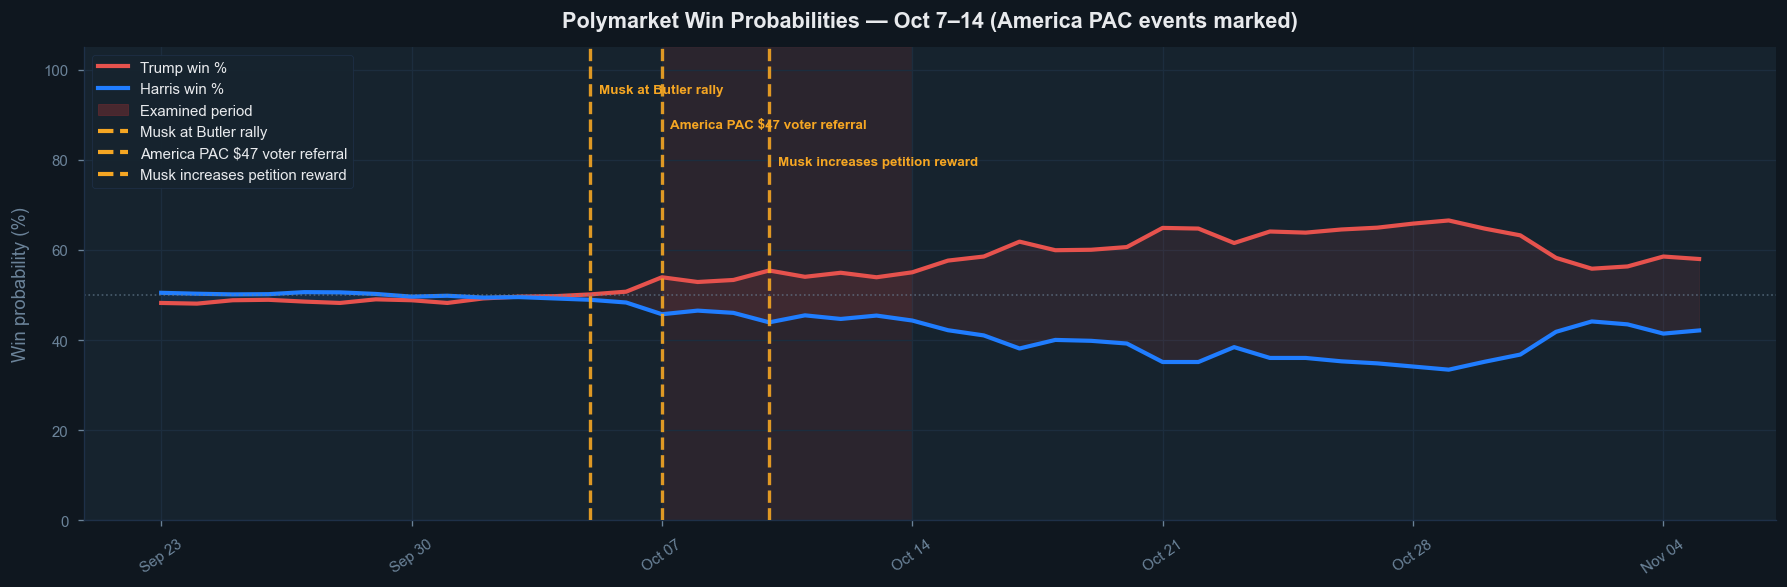

Polymarket on each event day:
  2024-10-05  Trump=50.1%  Harris=49.0%  -- Musk at Butler rally
  2024-10-07  Trump=54.0%  Harris=45.8%  -- America PAC $47 voter referral
  2024-10-10  Trump=55.5%  Harris=44.0%  -- Musk increases petition reward

7-day mean change around each event (post − pre):
  Musk at Butler rally                           Trump: +4.6 pp  Harris: -4.0 pp
  America PAC $47 voter referral                 Trump: +4.7 pp  Harris: -4.1 pp
  Musk increases petition reward                 Trump: +5.1 pp  Harris: -4.7 pp


In [91]:
ERA_START = pd.Timestamp('2024-10-07')
ERA_END   = pd.Timestamp('2024-10-14')
ERA_COLOR = '#a83232'

# ── Filter arc ─────────────────────────────────────────────────────────────────
poly_arc = poly[(poly['date'] >= ARC_START) & (poly['date'] <= ARC_END)].copy()
poly_arc = poly_arc.sort_values('date')

# ── Full arc plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COLOR)

ax.plot(poly_arc['date'], poly_arc['trump_pct'],  color=REPUBLICAN, linewidth=2.5, label='Trump win %')
ax.plot(poly_arc['date'], poly_arc['harris_pct'], color=DEMOCRAT,   linewidth=2.5, label='Harris win %')

ax.fill_between(poly_arc['date'], poly_arc['trump_pct'], poly_arc['harris_pct'],
                where=(poly_arc['trump_pct'].values >= poly_arc['harris_pct'].values),
                color=REPUBLICAN, alpha=0.10)
ax.fill_between(poly_arc['date'], poly_arc['trump_pct'], poly_arc['harris_pct'],
                where=(poly_arc['harris_pct'].values > poly_arc['trump_pct'].values),
                color=DEMOCRAT, alpha=0.10)
ax.axhline(50, color=TEXT_MUTED, linestyle=':', linewidth=1.0, alpha=0.6)

# ── Shade the examined period ──────────────────────────────────────────────────
ax.axvspan(ERA_START, ERA_END, color=ERA_COLOR, alpha=0.15, zorder=0, label='Examined period')

# ── Event lines & annotations ──────────────────────────────────────────────────
for i, (lbl, date, color) in enumerate(MUSK_EVENTS):
    ax.axvline(date, color=color, linestyle='--', linewidth=2, alpha=0.9, zorder=5)
    ax.annotate(lbl, xy=(date, 97 - i*8),
                xytext=(5, 0), textcoords='offset points',
                color=color, fontsize=8, fontweight='bold', va='top')

fmt_date_axis(ax)
ax.set_ylabel('Win probability (%)', color=TEXT_MUTED)
ax.set_ylim(0, 105)
ax.set_title('Polymarket Win Probabilities — Oct 7–14 (America PAC events marked)',
             color=TEXT_PRIMARY, fontweight='bold')

handles = [
    mlines.Line2D([], [], color=REPUBLICAN, linewidth=2.5, label='Trump win %'),
    mlines.Line2D([], [], color=DEMOCRAT,   linewidth=2.5, label='Harris win %'),
    mpatches.Patch(color=ERA_COLOR, alpha=0.35, label='Examined period'),
] + musk_legend_handles()
ax.legend(handles=handles, loc='upper left',
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9)
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Print point-in-time values ─────────────────────────────────────────────────
print('Polymarket on each event day:')
for lbl, date, _ in MUSK_EVENTS:
    row = poly_arc[poly_arc['date'] == date]
    if not row.empty:
        t = row['trump_pct'].values[0]
        h = row['harris_pct'].values[0]
        print(f'  {date.date()}  Trump={t:.1f}%  Harris={h:.1f}%  -- {lbl}')

print('\n7-day mean change around each event (post − pre):')
for lbl, date, _ in MUSK_EVENTS:
    pre  = poly_arc[(poly_arc['date'] >= date - pd.Timedelta(days=7)) & (poly_arc['date'] < date)]
    post = poly_arc[(poly_arc['date'] >  date) & (poly_arc['date'] <= date + pd.Timedelta(days=7))]
    if not pre.empty and not post.empty:
        dt = post['trump_pct'].mean()  - pre['trump_pct'].mean()
        dh = post['harris_pct'].mean() - pre['harris_pct'].mean()
        print(f'  {lbl:<45}  Trump: {dt:+.1f} pp  Harris: {dh:+.1f} pp')

### 1b. Polymarket Odds — Zoomed ±14 Days Around Each Event

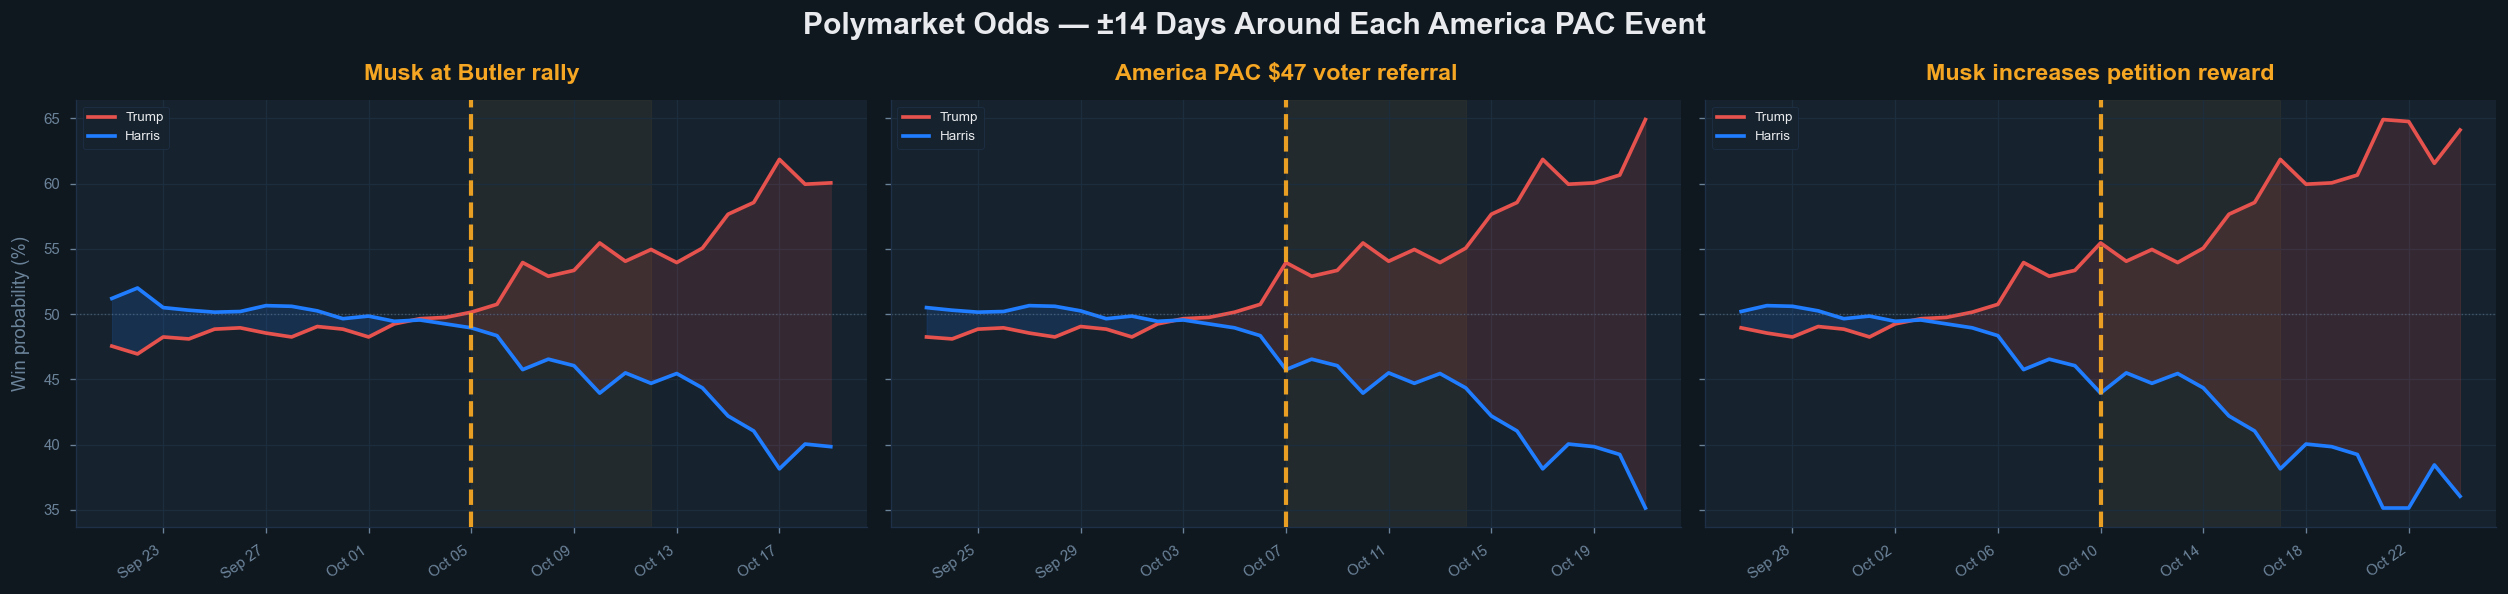

In [92]:
# Zoomed +/-14 days around each America PAC event
fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Polymarket Odds — ±14 Days Around Each America PAC Event',
             fontweight='bold', fontsize=18, color=TEXT_PRIMARY)

ZOOM = 14
for ax, (lbl, date, ev_color) in zip(axes, MUSK_EVENTS):
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    win = poly[(poly['date'] >= date - pd.Timedelta(days=ZOOM)) &
               (poly['date'] <= date + pd.Timedelta(days=ZOOM))].copy()
    if win.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                color=TEXT_MUTED, transform=ax.transAxes)
        continue
    ax.fill_between(win['date'], win['trump_pct'], win['harris_pct'],
                    where=(win['trump_pct'].values >= win['harris_pct'].values),
                    color=REPUBLICAN, alpha=0.15)
    ax.fill_between(win['date'], win['trump_pct'], win['harris_pct'],
                    where=(win['harris_pct'].values > win['trump_pct'].values),
                    color=DEMOCRAT, alpha=0.15)
    ax.plot(win['date'], win['trump_pct'],  color=REPUBLICAN, linewidth=2.2, label='Trump')
    ax.plot(win['date'], win['harris_pct'], color=DEMOCRAT,   linewidth=2.2, label='Harris')
    ax.axvline(date, color=ev_color, linestyle='--', linewidth=2.5, alpha=0.95, zorder=6)
    ax.axhline(50,   color=TEXT_MUTED, linestyle=':', linewidth=0.8, alpha=0.5)
    ax.axvspan(date, date + pd.Timedelta(days=7), color=ev_color, alpha=0.06, zorder=0)
    ax.set_title(lbl, color=ev_color, fontweight='bold', fontsize=14)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', color=TEXT_MUTED)
    ax.tick_params(axis='y', colors=TEXT_MUTED)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', fontsize=8,
              facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

axes[0].set_ylabel('Win probability (%)', color=TEXT_MUTED)
plt.tight_layout()
plt.show()

## 2. Volume & America PAC Mention Share — Bluesky & Reddit

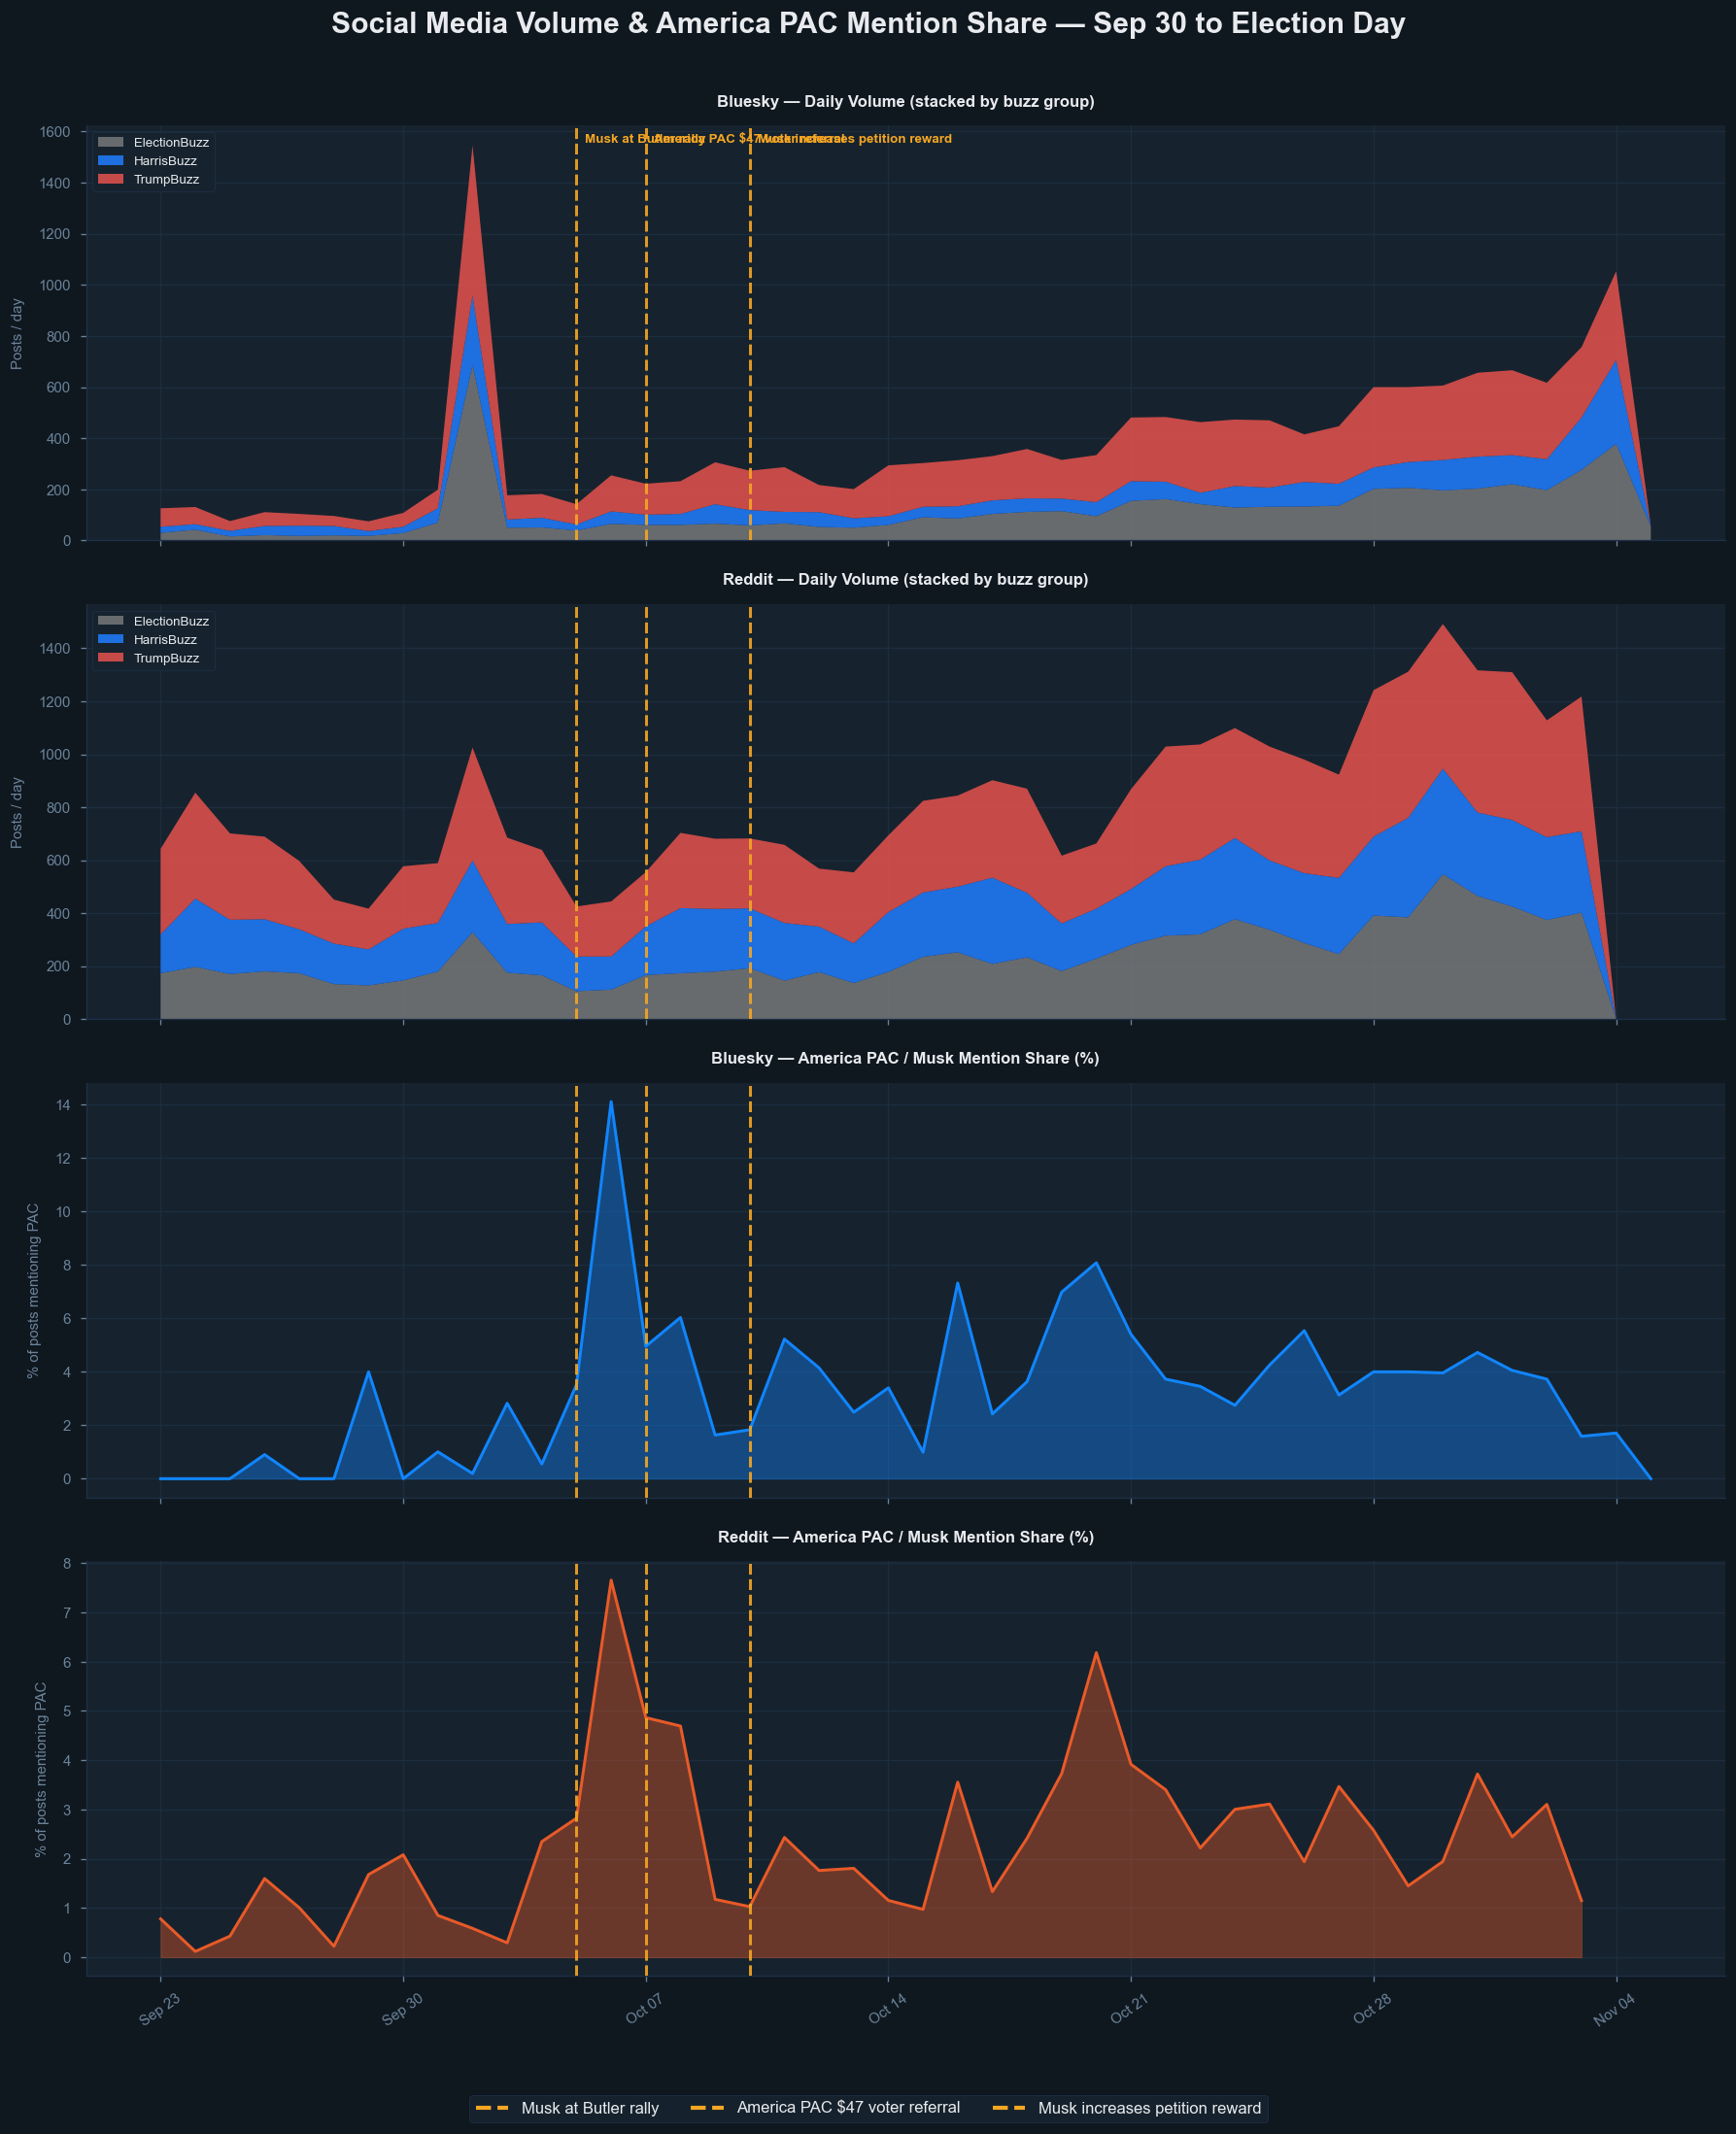

Peak America PAC mention days — Bluesky:
            sum  count      share
2024-10-06   36    255  14.117647
2024-10-20   27    334   8.083832
2024-10-16   23    314   7.324841
2024-10-19   22    315   6.984127
2024-10-08   14    232   6.034483

Peak America PAC mention days — Reddit:
            sum  count     share
2024-10-06   34    444  7.657658
2024-10-20   41    663  6.184012
2024-10-07   27    555  4.864865
2024-10-08   33    703  4.694168
2024-10-21   34    868  3.917051


In [94]:

# ── Filter arc period ──────────────────────────────────────────────────────────
bsky_arc   = bsky[(bsky['date']   >= ARC_START) & (bsky['date']   <= ARC_END)].copy()
reddit_arc = reddit[(reddit['date'] >= ARC_START) & (reddit['date'] <= ARC_END)].copy()

# ── Daily volume by buzz group ─────────────────────────────────────────────────
date_range = pd.date_range(ARC_START, ARC_END)

bsky_daily = (bsky_arc.groupby(['date', 'buzz_group'])
              .size().unstack(fill_value=0)
              .reindex(date_range, fill_value=0))
for c in BUZZ_ORDER:
    if c not in bsky_daily.columns: bsky_daily[c] = 0

reddit_daily = (reddit_arc.groupby(['date', 'buzz_group'])
                .size().unstack(fill_value=0)
                .reindex(date_range, fill_value=0))
for c in BUZZ_ORDER:
    if c not in reddit_daily.columns: reddit_daily[c] = 0

# ── Musk / America PAC mention share ──────────────────────────────────────────
PAC_TERMS = r'musk|america\s*pac|\bpac\b|petition|lottery|\$47|referral'

bsky_arc['pac_mention']   = bsky_arc['text_clean'].str.contains(PAC_TERMS, case=False, na=False)
reddit_arc['pac_mention'] = reddit_arc['text_clean'].str.contains(PAC_TERMS, case=False, na=False)

bsky_pac_share = (bsky_arc.groupby('date')['pac_mention']
                  .agg(['sum', 'count'])
                  .reindex(date_range, fill_value=0))
bsky_pac_share['share'] = (bsky_pac_share['sum'] / bsky_pac_share['count'].replace(0, np.nan) * 100)

reddit_pac_share = (reddit_arc.groupby('date')['pac_mention']
                    .agg(['sum', 'count'])
                    .reindex(date_range, fill_value=0))
reddit_pac_share['share'] = (reddit_pac_share['sum'] / reddit_pac_share['count'].replace(0, np.nan) * 100)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Social Media Volume & America PAC Mention Share — Sep 30 to Election Day',
             color=TEXT_PRIMARY, fontsize=18, fontweight='bold', y=1.01)

# Panel 1 — Bluesky stacked volume
ax = axes[0]
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.stackplot(bsky_daily.index,
             bsky_daily['ElectionBuzz'],
             bsky_daily['HarrisBuzz'],
             bsky_daily['TrumpBuzz'],
             labels=['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz'],
             colors=[NEUTRAL, DEMOCRAT, REPUBLICAN], alpha=0.85)
ax.set_ylabel('Posts / day', color=TEXT_MUTED, fontsize=9)
ax.set_title('Bluesky — Daily Volume (stacked by buzz group)', color=TEXT_PRIMARY, fontsize=10, fontweight='bold')
ax.legend(loc='upper left', facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, fontsize=8)

# Panel 2 — Reddit stacked volume
ax = axes[1]
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.stackplot(reddit_daily.index,
             reddit_daily['ElectionBuzz'],
             reddit_daily['HarrisBuzz'],
             reddit_daily['TrumpBuzz'],
             labels=['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz'],
             colors=[NEUTRAL, DEMOCRAT, REPUBLICAN], alpha=0.85)
ax.set_ylabel('Posts / day', color=TEXT_MUTED, fontsize=9)
ax.set_title('Reddit — Daily Volume (stacked by buzz group)', color=TEXT_PRIMARY, fontsize=10, fontweight='bold')
ax.legend(loc='upper left', facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, fontsize=8)

# Panel 3 — Bluesky PAC mention share (house style: BLUESKY_BLUE)
ax = axes[2]
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.fill_between(bsky_pac_share.index, bsky_pac_share['share'],
                color=BLUESKY_BLUE, alpha=0.4)
ax.plot(bsky_pac_share.index, bsky_pac_share['share'],
        color=BLUESKY_BLUE, linewidth=1.8)
ax.set_ylabel('% of posts mentioning PAC', color=TEXT_MUTED, fontsize=9)
ax.set_title('Bluesky — America PAC / Musk Mention Share (%)', color=TEXT_PRIMARY, fontsize=10, fontweight='bold')

# Panel 4 — Reddit PAC mention share (house style: REDDIT_ORG)
ax = axes[3]
ax.set_facecolor(BG_PANEL)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.fill_between(reddit_pac_share.index, reddit_pac_share['share'],
                color=REDDIT_ORG, alpha=0.4)
ax.plot(reddit_pac_share.index, reddit_pac_share['share'],
        color=REDDIT_ORG, linewidth=1.8)
ax.set_ylabel('% of posts mentioning PAC', color=TEXT_MUTED, fontsize=9)
ax.set_title('Reddit — America PAC / Musk Mention Share (%)', color=TEXT_PRIMARY, fontsize=10, fontweight='bold')

# ── Event lines on all panels ──────────────────────────────────────────────────
for ax in axes:
    for lbl, date, color in MUSK_EVENTS:
        ax.axvline(date, color=color, linestyle='--', linewidth=1.8, alpha=0.9, zorder=5)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', colors=TEXT_MUTED)

# Annotate event names on top panel only
for i, (lbl, date, color) in enumerate(MUSK_EVENTS):
    axes[0].annotate(lbl, xy=(date, axes[0].get_ylim()[1]),
                     xytext=(5, -5), textcoords='offset points',
                     color=color, fontsize=8, fontweight='bold', va='top')

fmt_date_axis(axes[3])
fig.legend(handles=[mlines.Line2D([], [], color=c, linestyle='--', linewidth=2.5, label=l)
                    for l, _, c in MUSK_EVENTS],
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=3,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95)
plt.tight_layout(rect=[0, 0.04, 1, 1], h_pad=1.5)
plt.show()

# ── Print peak mention days ────────────────────────────────────────────────────
print('Peak America PAC mention days — Bluesky:')
print(bsky_pac_share.nlargest(5, 'share')[['sum', 'count', 'share']].to_string())
print('\nPeak America PAC mention days — Reddit:')
print(reddit_pac_share.nlargest(5, 'share')[['sum', 'count', 'share']].to_string())

## 3. TF-IDF Term Shift — Vocabulary Change After Each Event

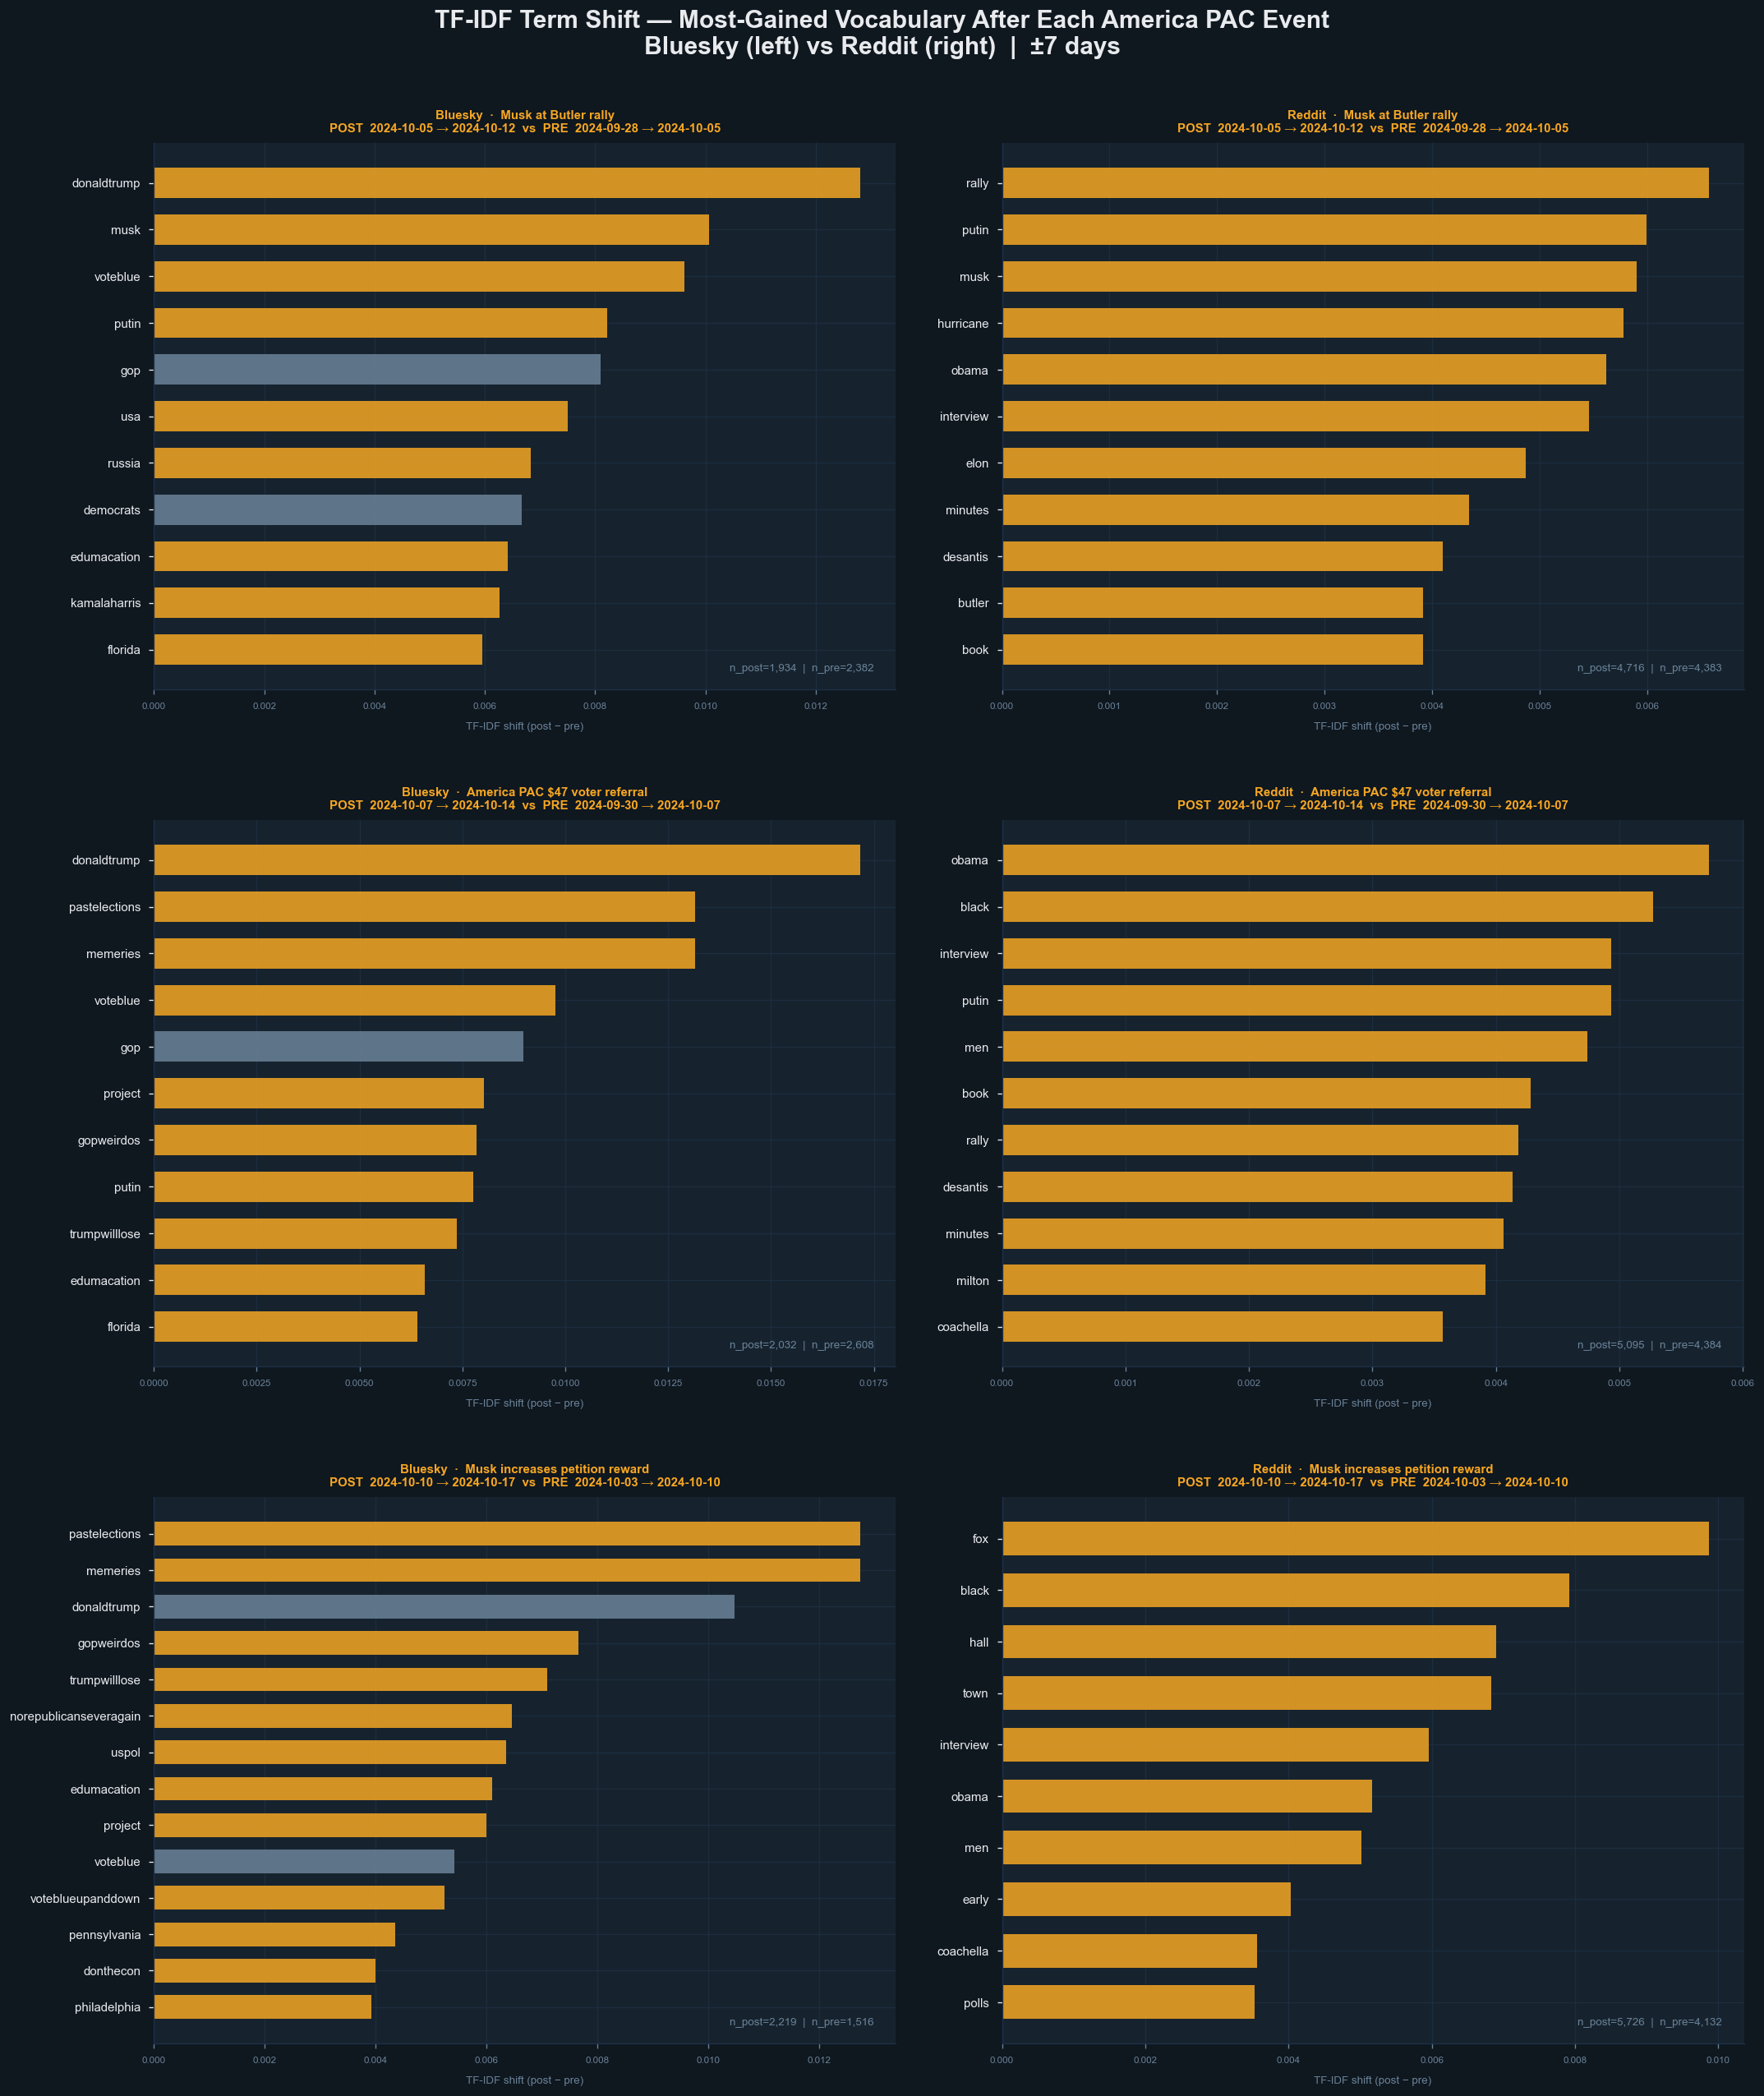

In [95]:
# ── TF-IDF term shift around each America PAC event (Bluesky) ─────────────────
STOP_EXTRA = {
    'trump', 'harris', 'kamala', 'donald', 'president', 'presidential',
    'election', 'vote', 'voting', 'voter', 'voters', 'campaign', 'like',
    'people', 'said', 'would', 'just', 'got', 'going', 'today', 'time',
    'maga', 'republican', 'democrat', 'party', 'america', 'american',
    'political', 'news', 'one', 'new', 'make', 'will', 'also', 'say',
}
LOCAL_EVENTS = MUSK_EVENTS  # Butler rally + PAC referral + petition
fig, axes = plt.subplots(len(LOCAL_EVENTS), 2, figsize=(18, len(LOCAL_EVENTS) * 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('TF-IDF Term Shift — Most-Gained Vocabulary After Each America PAC Event\n'
             'Bluesky (left) vs Reddit (right)  |  ±7 days',
             color=TEXT_PRIMARY, fontsize=18, fontweight='bold', y=1.01)

PLATFORMS = [
    ('Bluesky', bsky,   'text_clean', 'date', BLUESKY_BLUE),
    ('Reddit',  reddit, 'text_clean', 'date', REDDIT_ORG),
]


for row, (lbl, date, ev_color) in enumerate(LOCAL_EVENTS):
    for col, (plat_name, df, text_col, date_col, plat_color) in enumerate(PLATFORMS):
        ax = axes[row][col] if len(LOCAL_EVENTS) > 1 else axes[col]
        ax.set_facecolor(BG_PANEL)
        for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)

        # ── pre / post windows ─────────────────────────────────────────────────
        pre  = df[(df[date_col] >= date - pd.Timedelta(days=WINDOW_DAYS)) &
                  (df[date_col] <  date)]
        post = df[(df[date_col] >= date) &
                  (df[date_col] <= date + pd.Timedelta(days=WINDOW_DAYS))]

        gained = top_tfidf_gained(pre[text_col].tolist(), post[text_col].tolist(), n=15)

        # drop generic stopwords
        gained = gained[~gained.index.isin(STOP_EXTRA)]

        if gained.empty:
            ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center',
                    color=TEXT_MUTED, transform=ax.transAxes)
        else:
            # highlight terms that are event-specific (not in pre-window top-15)
            pre_top = top_tfidf_gained(
                ['placeholder']*10,   # dummy — we just want pre vocab
                pre[text_col].tolist(), n=15
            ).index.tolist() if len(pre) >= 5 else []

            terms  = gained.index[::-1]
            values = gained.values[::-1]
            colors = [ev_color if t not in pre_top else TEXT_MUTED for t in terms]

            bars = ax.barh(terms, values, color=colors, edgecolor='none',
                           height=0.65, alpha=0.85)

        ax.set_title(
            f'{plat_name}  ·  {lbl}\n'
            f'POST  {date.date()} → {(date + pd.Timedelta(days=WINDOW_DAYS)).date()}  '
            f'vs  PRE  {(date - pd.Timedelta(days=WINDOW_DAYS)).date()} → {date.date()}',
            color=ev_color, fontsize=9, fontweight='bold', pad=8
        )
        ax.set_xlabel('TF-IDF shift (post − pre)', color=TEXT_MUTED, fontsize=8)
        ax.tick_params(axis='y', labelsize=9, colors=TEXT_PRIMARY)
        ax.tick_params(axis='x', labelsize=7, colors=TEXT_MUTED)
        ax.grid(axis='x', color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.annotate(f'n_post={len(post):,}  |  n_pre={len(pre):,}',
                    xy=(0.97, 0.03), xycoords='axes fraction',
                    ha='right', va='bottom', fontsize=8, color=TEXT_MUTED)

plt.tight_layout(h_pad=4, w_pad=3)
plt.show()

## 4. VADER Sentiment — Pre vs Post Each Event

Scoring 5,758 Bluesky posts and 12,917 Reddit posts...
Done.

Sentiment pre vs post:
                         event platform   buzz_group       pre      post     delta
          Musk at Butler rally  Bluesky    TrumpBuzz -0.069180 -0.102153 -0.032973
          Musk at Butler rally  Bluesky   HarrisBuzz  0.153212  0.106413 -0.046798
          Musk at Butler rally  Bluesky ElectionBuzz  0.069579  0.011953 -0.057625
          Musk at Butler rally   Reddit    TrumpBuzz -0.081499 -0.034368  0.047131
          Musk at Butler rally   Reddit   HarrisBuzz -0.027090 -0.004726  0.022364
          Musk at Butler rally   Reddit ElectionBuzz -0.034321 -0.030183  0.004138
America PAC $47 voter referral  Bluesky    TrumpBuzz -0.076635 -0.116391 -0.039757
America PAC $47 voter referral  Bluesky   HarrisBuzz  0.149317  0.081827 -0.067489
America PAC $47 voter referral  Bluesky ElectionBuzz  0.070309 -0.010213 -0.080523
America PAC $47 voter referral   Reddit    TrumpBuzz -0.060137 -0.061452 -0.001315
Am

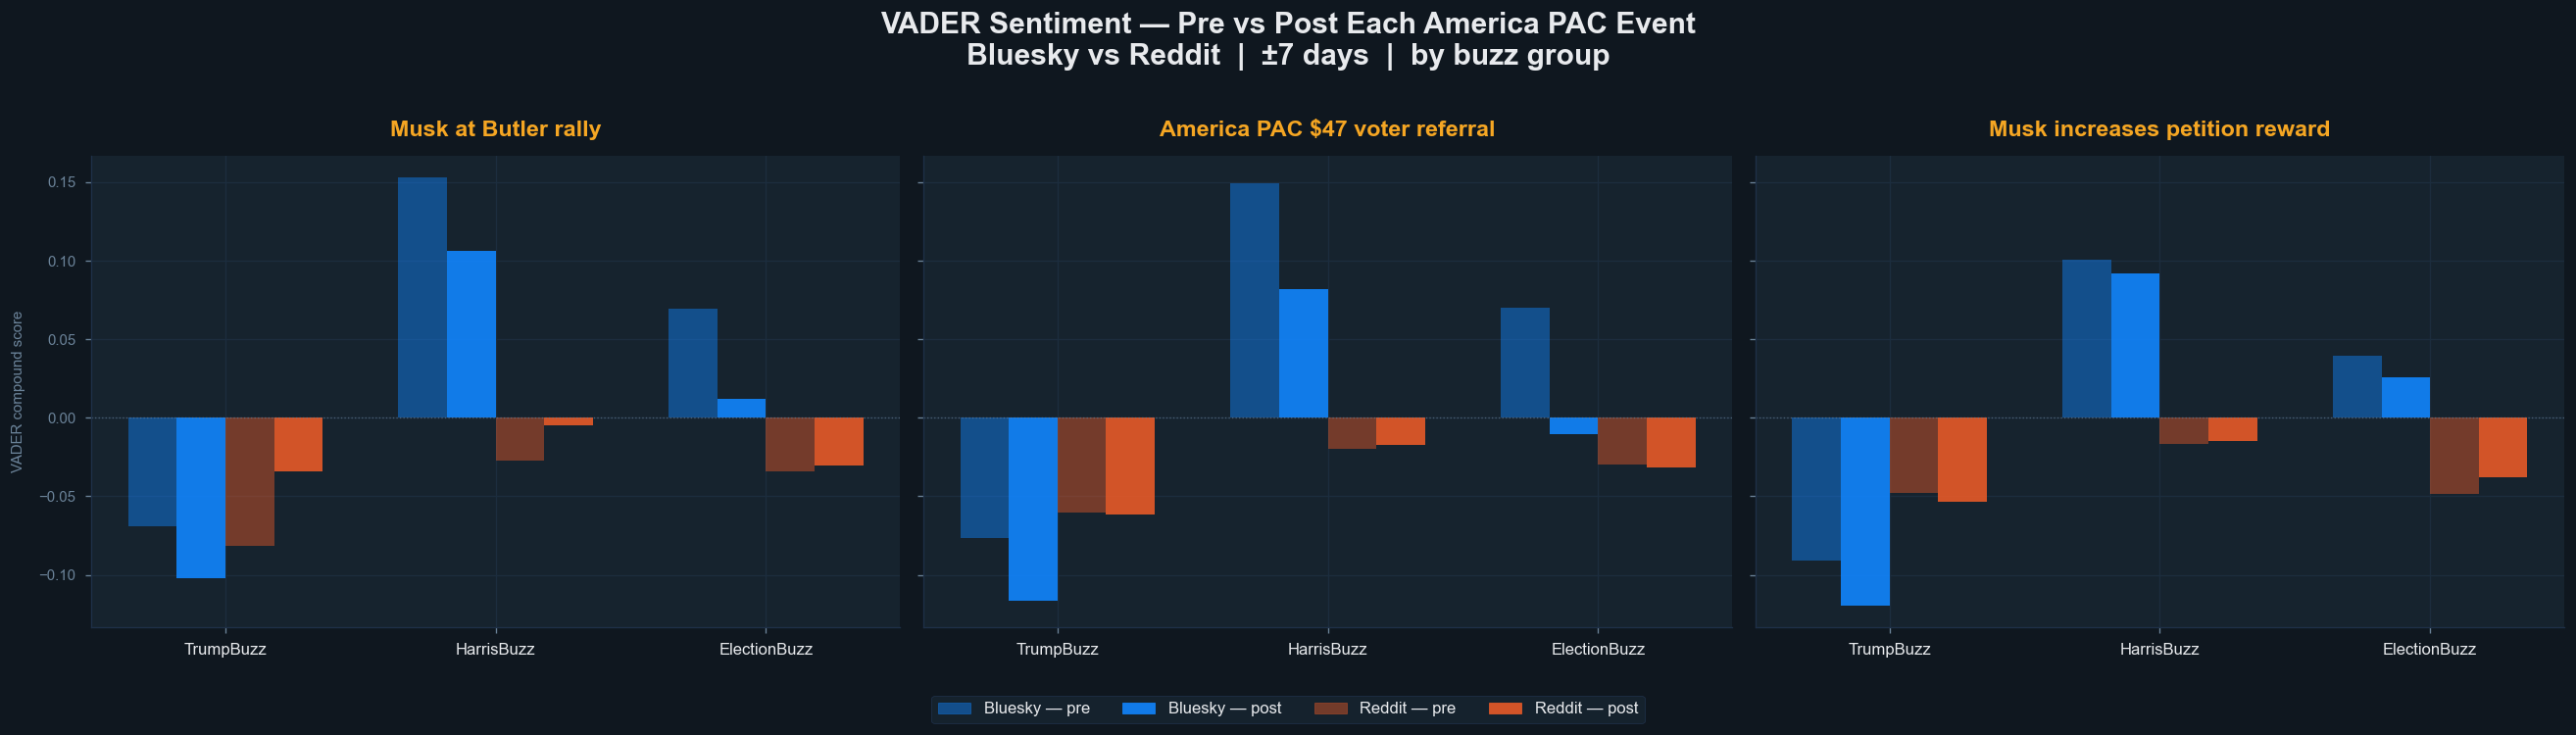

In [96]:
analyzer = SentimentIntensityAnalyzer()

# ── Score both platforms in the two event windows only ────────────────────────
all_dates = set()
for _, date, _ in MUSK_EVENTS:
    for d in pd.date_range(date - pd.Timedelta(days=WINDOW_DAYS),
                           date + pd.Timedelta(days=WINDOW_DAYS)):
        all_dates.add(d.normalize())

bsky_w   = bsky[bsky['date'].isin(all_dates)].copy()
reddit_w = reddit[reddit['date'].isin(all_dates)].copy()

print(f'Scoring {len(bsky_w):,} Bluesky posts and {len(reddit_w):,} Reddit posts...')

bsky_w['vader']   = bsky_w['text_clean'].fillna('').apply(
    lambda t: analyzer.polarity_scores(t)['compound'])
reddit_w['vader'] = reddit_w['text_clean'].fillna('').apply(
    lambda t: analyzer.polarity_scores(t)['compound'])

print('Done.')

# ── Pre/post means per event per platform per buzz group ───────────────────────
rows = []
for lbl, date, ev_color in MUSK_EVENTS:
    for platform, df in [('Bluesky', bsky_w), ('Reddit', reddit_w)]:
        pre  = df[(df['date'] >= date - pd.Timedelta(days=WINDOW_DAYS)) &
                  (df['date'] <  date)]
        post = df[(df['date'] >= date) &
                  (df['date'] <= date + pd.Timedelta(days=WINDOW_DAYS))]
        for grp in BUZZ_ORDER:
            pre_m  = pre[pre['buzz_group']  == grp]['vader'].mean()
            post_m = post[post['buzz_group'] == grp]['vader'].mean()
            rows.append({'event': lbl, 'platform': platform,
                         'buzz_group': grp,
                         'pre': pre_m, 'post': post_m,
                         'delta': post_m - pre_m})

results = pd.DataFrame(rows)
print('\nSentiment pre vs post:')
print(results.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('VADER Sentiment — Pre vs Post Each America PAC Event\n'
             'Bluesky vs Reddit  |  ±7 days  |  by buzz group',
             color=TEXT_PRIMARY, fontsize=18, fontweight='bold', y=1.02)

SENT_COLORS = {'TrumpBuzz': REPUBLICAN, 'HarrisBuzz': DEMOCRAT, 'ElectionBuzz': NEUTRAL}
x      = np.arange(len(BUZZ_ORDER))
width  = 0.18

for col, (lbl, date, ev_color) in enumerate(MUSK_EVENTS):
    ax = axes[col]
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(SPINE_COLOR)

    ev_data = results[results['event'] == lbl]

    for i, platform in enumerate(['Bluesky', 'Reddit']):
        p_data = ev_data[ev_data['platform'] == platform]
        pre_vals  = [p_data[p_data['buzz_group'] == g]['pre'].values[0]
                     if len(p_data[p_data['buzz_group'] == g]) else np.nan
                     for g in BUZZ_ORDER]
        post_vals = [p_data[p_data['buzz_group'] == g]['post'].values[0]
                     if len(p_data[p_data['buzz_group'] == g]) else np.nan
                     for g in BUZZ_ORDER]

        offset_pre  = x + (i * 2    ) * width - 1.5 * width
        offset_post = x + (i * 2 + 1) * width - 1.5 * width

        plat_color = BLUESKY_BLUE if platform == 'Bluesky' else REDDIT_ORG
        ax.bar(offset_pre,  pre_vals,  width=width, color=plat_color,
               alpha=0.45, label=f'{platform} pre',  edgecolor='none')
        ax.bar(offset_post, post_vals, width=width, color=plat_color,
               alpha=0.90, label=f'{platform} post', edgecolor='none')


    ax.axhline(0, color=TEXT_MUTED, linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(BUZZ_ORDER, color=TEXT_PRIMARY, fontsize=10)
    ax.set_title(lbl, color=ev_color, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', colors=TEXT_MUTED)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)

axes[0].set_ylabel('VADER compound score', color=TEXT_MUTED, fontsize=9)

# ── Single clean legend ────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=BLUESKY_BLUE, alpha=0.45, label='Bluesky — pre'),
    mpatches.Patch(color=BLUESKY_BLUE, alpha=0.90, label='Bluesky — post'),
    mpatches.Patch(color=REDDIT_ORG,   alpha=0.45, label='Reddit — pre'),
    mpatches.Patch(color=REDDIT_ORG,   alpha=0.90, label='Reddit — post'),
]
fig.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=4,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

1) **The Bluesky vs Reddit demographic split is clearly visible**
    
    For HarrisBuzz, Bluesky pre-scores around +0.15 while Reddit sits near 0 or slightly negative. This directly confirms that Harris supporters on Bluesky write in a more positive, enthusiastic tone than the broader Reddit audience — consistent with Bluesky's known concentration of left-leaning, politically engaged users who actively chose to migrate there from Twitter precisely because of political alignment.

2) **TrumpBuzz tells the more interesting story**
    
    Bluesky TrumpBuzz is negative on both platforms pre-event (around −0.08 to −0.11), but Bluesky goes more negative post-event while Reddit stays relatively stable. This means the America PAC events triggered a stronger negative reaction on Bluesky than on Reddit — the critical, left-leaning Bluesky audience responded more intensely to the lottery/referral scheme than Reddit's more mixed audience did.

3) **The post-event sentiment drop is consistent across both events**
    
    Both panels show the same pattern — Bluesky TrumpBuzz drops further negative post-event, Reddit TrumpBuzz barely moves. This consistency across two separate events three days apart strengthens the finding: it is not a one-off spike but a structural platform difference in how the America PAC activity was received.

--> Bluesky amplifies critical framing of Republican PAC activity more strongly than Reddit, reflecting its demographically distinct, left-leaning user base — platform choice is not neutral, it systematically filters the sentiment signal you observe.

## 5. Musk Mention Volume by Buzz Group

Musk mention share per buzz group — pre vs post each event:

  Musk at Butler rally (2024-10-05)
    Bluesky
      TrumpBuzz        pre=  2.1%  post=  7.8%  Δ=+5.7 pp
      HarrisBuzz       pre=  0.0%  post=  1.2%  Δ=+1.2 pp
      ElectionBuzz     pre=  0.3%  post=  2.1%  Δ=+1.8 pp
    Reddit
      TrumpBuzz        pre=  2.2%  post=  5.9%  Δ=+3.7 pp
      HarrisBuzz       pre=  0.6%  post=  0.9%  Δ=+0.3 pp
      ElectionBuzz     pre=  0.3%  post=  1.2%  Δ=+1.0 pp

  America PAC $47 voter referral (2024-10-07)
    Bluesky
      TrumpBuzz        pre=  4.6%  post=  5.4%  Δ=+0.8 pp
      HarrisBuzz       pre=  0.6%  post=  1.4%  Δ=+0.9 pp
      ElectionBuzz     pre=  1.5%  post=  1.5%  Δ=+0.0 pp
    Reddit
      TrumpBuzz        pre=  4.5%  post=  3.9%  Δ=-0.5 pp
      HarrisBuzz       pre=  0.6%  post=  0.9%  Δ=+0.2 pp
      ElectionBuzz     pre=  0.5%  post=  1.1%  Δ=+0.6 pp

  Musk increases petition reward (2024-10-10)
    Bluesky
      TrumpBuzz        pre=  7.3%  post=  4.8%  Δ=-2.5 

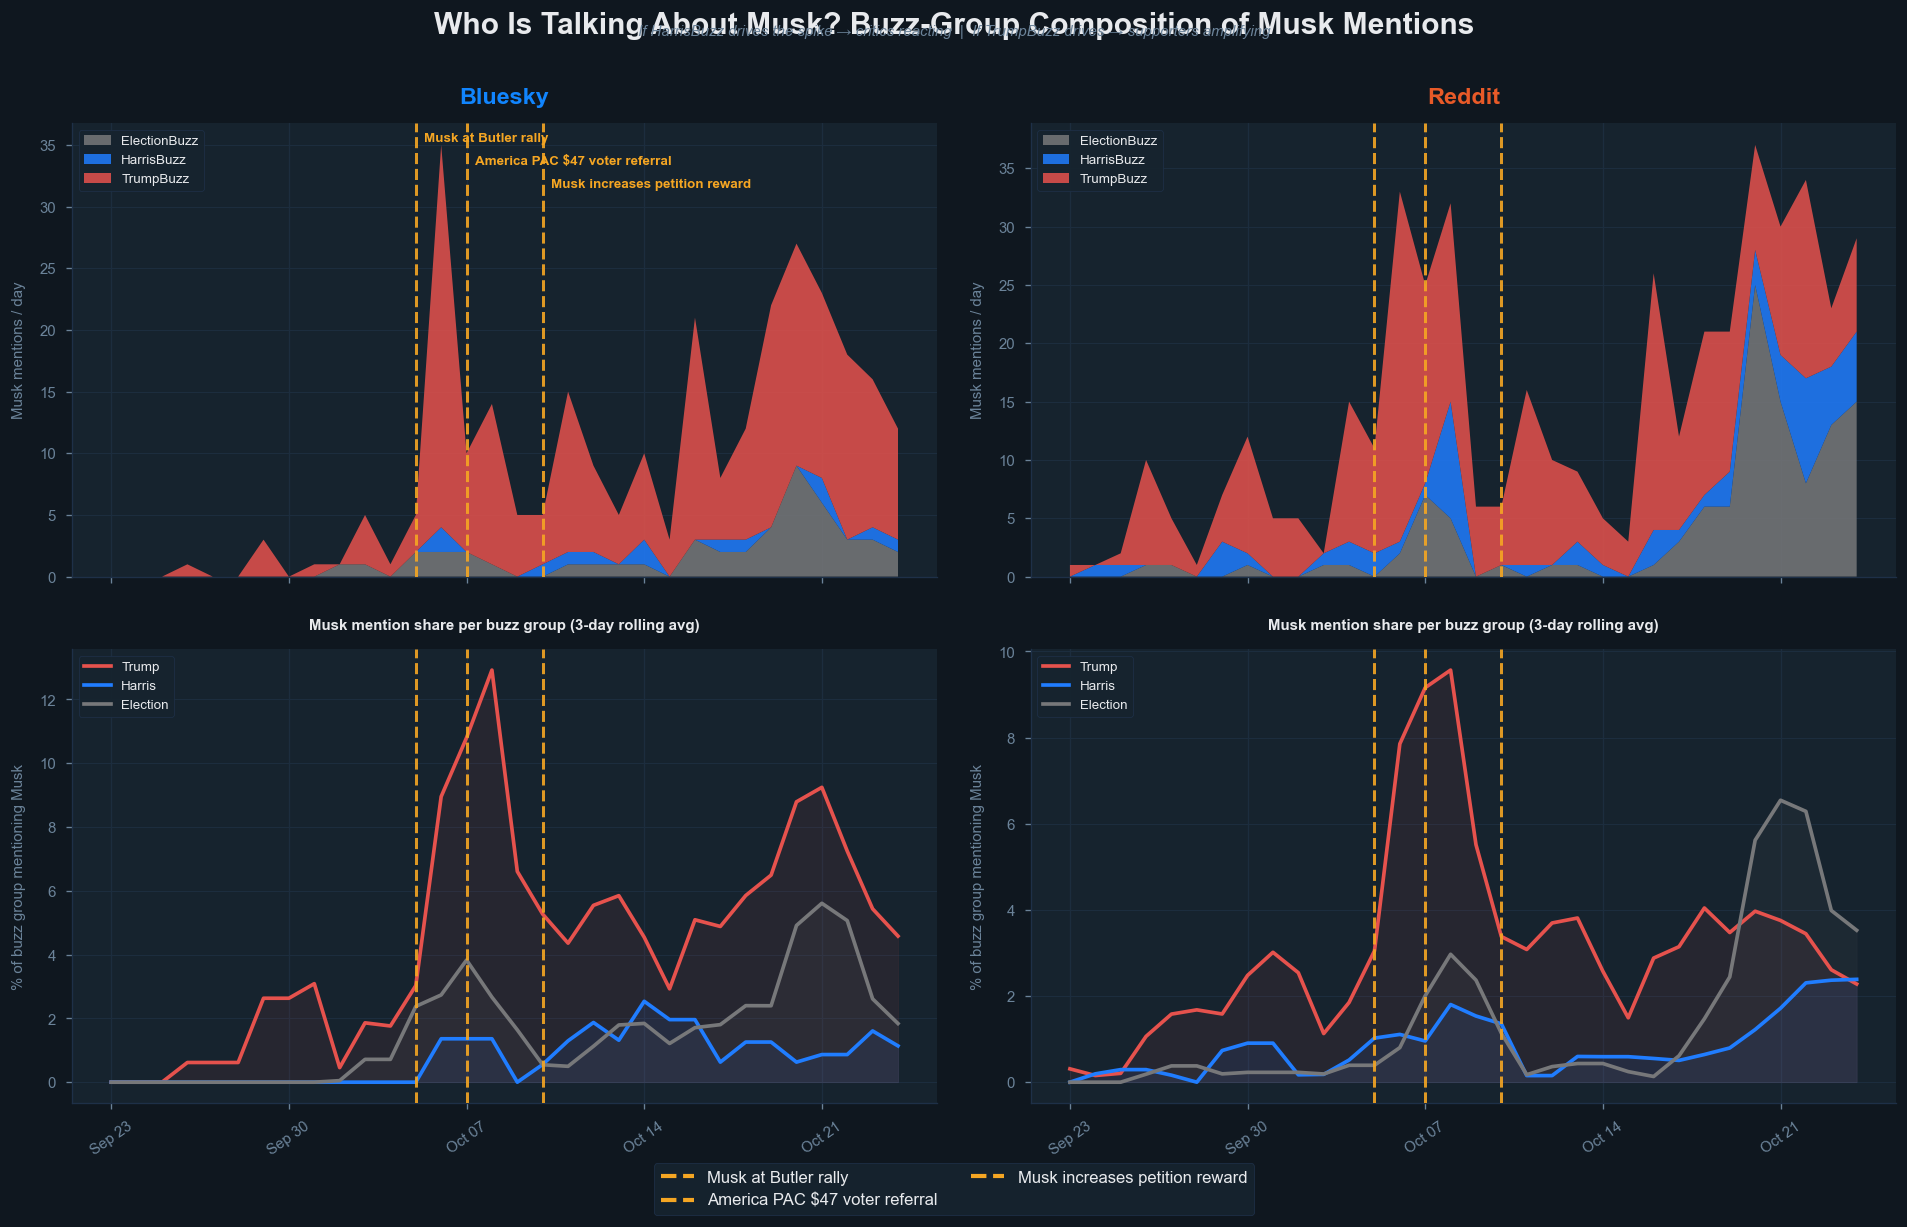

In [97]:
# ── Musk mention volume by buzz group — agenda-setting analysis ────────────────
MUSK_TERMS = r'\bmusk\b|elonmusk|@musk'

SYNTH_START = pd.Timestamp('2024-09-23')   # 2 weeks before E1
SYNTH_END   = pd.Timestamp('2024-10-24')
date_range  = pd.date_range(SYNTH_START, SYNTH_END)

# ── Flag Musk mentions ─────────────────────────────────────────────────────────
bsky_s   = bsky[(bsky['date']     >= SYNTH_START) &
                (bsky['date']     <= SYNTH_END)].copy()
reddit_s = reddit[(reddit['date'] >= SYNTH_START) &
                  (reddit['date'] <= SYNTH_END)].copy()

bsky_s['musk_mention']   = bsky_s['text_clean'].str.contains(
    MUSK_TERMS, case=False, na=False, regex=True)
reddit_s['musk_mention'] = reddit_s['text_clean'].str.contains(
    MUSK_TERMS, case=False, na=False, regex=True)

# ── Daily Musk mention count per buzz group ────────────────────────────────────
def musk_by_group(df):
    return (df[df['musk_mention']]
            .groupby(['date', 'buzz_group'])
            .size()
            .unstack(fill_value=0)
            .reindex(date_range, fill_value=0))

bsky_musk   = musk_by_group(bsky_s)
reddit_musk = musk_by_group(reddit_s)

for grp in BUZZ_ORDER:
    if grp not in bsky_musk.columns:   bsky_musk[grp]   = 0
    if grp not in reddit_musk.columns: reddit_musk[grp] = 0

# ── Daily Musk mention SHARE per buzz group ────────────────────────────────────
def musk_share_by_group(mention_df, raw_df):
    """What % of each buzz group's posts mention Musk each day?"""
    total = (raw_df.groupby(['date', 'buzz_group'])
             .size()
             .unstack(fill_value=0)
             .reindex(date_range, fill_value=0))
    share = (mention_df / total.replace(0, np.nan) * 100)
    return share

bsky_share   = musk_share_by_group(bsky_musk,   bsky_s)
reddit_share = musk_share_by_group(reddit_musk, reddit_s)

# ── Print pre/post breakdown ───────────────────────────────────────────────────
print('Musk mention share per buzz group — pre vs post each event:')
for lbl, date, _ in MUSK_EVENTS:
    print(f'\n  {lbl} ({date.date()})')
    for platform, share_df in [('Bluesky', bsky_share),
                                ('Reddit',  reddit_share)]:
        pre  = share_df[(share_df.index >= date - pd.Timedelta(days=WINDOW_DAYS)) &
                        (share_df.index <  date)]
        post = share_df[(share_df.index >= date) &
                        (share_df.index <= date + pd.Timedelta(days=WINDOW_DAYS))]
        print(f'    {platform}')
        for grp in BUZZ_ORDER:
            if grp not in share_df.columns: continue
            pre_m  = pre[grp].mean()
            post_m = post[grp].mean()
            print(f'      {grp:<15}  pre={pre_m:5.1f}%  '
                  f'post={post_m:5.1f}%  Δ={post_m-pre_m:+.1f} pp')

# ── Plot: 2×2 — volume (top) and share (bottom) × Bluesky / Reddit ────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(
    'Who Is Talking About Musk? Buzz-Group Composition of Musk Mentions',
    color=TEXT_PRIMARY, fontsize=18, fontweight='bold', y=1.01
)
fig.text(0.5, 0.99,
         'If HarrisBuzz drives the spike → critics reacting  |  '
         'If TrumpBuzz drives → supporters amplifying',
         ha='center', color=TEXT_MUTED, fontsize=9, style='italic')

BUZZ_COLORS_LOCAL = {
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': NEUTRAL,
}

for col, (platform, vol_df, share_df) in enumerate([
    ('Bluesky', bsky_musk,   bsky_share),
    ('Reddit',  reddit_musk, reddit_share),
]):
    plat_color = BLUESKY_BLUE if platform == 'Bluesky' else REDDIT_ORG

    # ── Row 0: stacked volume ──────────────────────────────────────────────────
    ax = axes[0][col]
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(SPINE_COLOR)

    ax.stackplot(date_range,
                 vol_df['ElectionBuzz'],
                 vol_df['HarrisBuzz'],
                 vol_df['TrumpBuzz'],
                 labels=['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz'],
                 colors=[NEUTRAL, DEMOCRAT, REPUBLICAN], alpha=0.85)
    ax.set_ylabel('Musk mentions / day', color=TEXT_MUTED, fontsize=9)
    ax.set_title(platform, color=plat_color, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TEXT_MUTED)

    # ── Row 1: share lines per buzz group ──────────────────────────────────────
    ax = axes[1][col]
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(SPINE_COLOR)

    for grp in BUZZ_ORDER:
        if grp not in share_df.columns: continue
        smooth = share_df[grp].rolling(3, min_periods=1).mean()
        ax.plot(date_range, smooth,
                color=BUZZ_COLORS_LOCAL[grp],
                linewidth=2.2, label=grp.replace('Buzz', ''))
        ax.fill_between(date_range, smooth,
                        color=BUZZ_COLORS_LOCAL[grp], alpha=0.08)

    ax.set_ylabel('% of buzz group mentioning Musk',
                  color=TEXT_MUTED, fontsize=9)
    ax.set_title('Musk mention share per buzz group (3-day rolling avg)',
                 color=TEXT_PRIMARY, fontsize=9, fontweight='bold')
    ax.legend(loc='upper left', facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TEXT_MUTED)

# ── Event lines on all panels ──────────────────────────────────────────────────
for ax in axes.flat:
    for lbl, date, color in MUSK_EVENTS:
        ax.axvline(date, color=color, linestyle='--',
                   linewidth=1.8, alpha=0.9, zorder=5)
    ax.tick_params(axis='y', colors=TEXT_MUTED)

for i, (lbl, date, color) in enumerate(MUSK_EVENTS):
    axes[0][0].annotate(lbl, xy=(date, axes[0][0].get_ylim()[1]),
                        xytext=(5, -5 - i*14), textcoords='offset points',
                        color=color, fontsize=8, fontweight='bold', va='top')

fmt_date_axis(axes[1][0])
fmt_date_axis(axes[1][1])
fig.legend(handles=musk_legend_handles(), loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=2,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95)
plt.tight_layout(rect=[0, 0.04, 1, 1], h_pad=2, w_pad=2)
plt.show()

## 6. NER — SpaCy Entity Analysis

In [98]:
import spacy
print(spacy.__version__)

# check which models are installed
from spacy.cli import info
info()

3.8.11


{'spacy_version': '3.8.11',
 'location': 'c:\\Users\\verme_hzys4y0\\miniconda3\\envs\\SWMA2026\\Lib\\site-packages\\spacy',
 'platform': 'Windows-10-10.0.26200-SP0',
 'python_version': '3.11.14',
 'pipelines': {}}

In [99]:
import subprocess
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], 
               check=True)

CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [100]:
nlp = spacy.load('en_core_web_sm')
print(f'Model loaded: {nlp.meta["name"]} v{nlp.meta["version"]}')

# quick sanity check
doc = nlp("Elon Musk and Donald Trump met in Pennsylvania.")
for ent in doc.ents:
    print(f'  {ent.text:<20} {ent.label_}')

Model loaded: core_web_sm v3.8.0
  Elon Musk            PERSON
  Donald Trump         PERSON
  Pennsylvania         GPE


In [101]:
from collections import Counter

SYNTH_START = pd.Timestamp('2024-09-23')
SYNTH_END   = pd.Timestamp('2024-10-24')

print(f'Arc: {SYNTH_START.date()} → {SYNTH_END.date()}')
print(f'E1 referral : {E1_REFERRAL.date()}')
print(f'E2 petition : {E2_PETITION.date()}')

Arc: 2024-09-23 → 2024-10-24
E1 referral : 2024-10-07
E2 petition : 2024-10-10


In [ ]:
# ── Updated window & both platforms ───────────────────────────────────────────
SYNTH_START = pd.Timestamp('2024-09-21')
E_START     = pd.Timestamp('2024-10-05')
SYNTH_END   = pd.Timestamp('2024-10-31')

# ── Combine Bluesky + Reddit ───────────────────────────────────────────────────
bsky_arc   = bsky[(bsky['date']     >= SYNTH_START) &
                  (bsky['date']     <= SYNTH_END)].copy()
reddit_arc = reddit[(reddit['date'] >= SYNTH_START) &
                    (reddit['date'] <= SYNTH_END)].copy()

arc_posts = pd.concat([bsky_arc, reddit_arc], ignore_index=True)

pre_posts  = arc_posts[arc_posts['date'] <  E_START]['text_clean'].dropna()
post_posts = arc_posts[arc_posts['date'] >= E_START]['text_clean'].dropna()

print(f'Bluesky  in arc : {len(bsky_arc):,}')
print(f'Reddit   in arc : {len(reddit_arc):,}')
print(f'Combined in arc : {len(arc_posts):,}')
print(f'Pre  ({SYNTH_START.date()} → {E_START.date()})  : {len(pre_posts):,} posts')
print(f'Post ({E_START.date()}  → {SYNTH_END.date()}) : {len(post_posts):,} posts')
print(f'\nBuzz group breakdown:')
print(arc_posts['buzz_group'].value_counts().to_string())

# ── NER helper functions ───────────────────────────────────────────────────────
MUSK_VARIANTS = {'elon musk', 'musk', 'elon', 'elonmusk'}

def normalize(name):
    return 'elon musk' if name in MUSK_VARIANTS else name

FORCE_PERSONS = {
    'trump':          r'\b(trump|donald trump|donaldtrump)\b',
    'harris':         r'\b(harris|kamala|kamala harris)\b',
    'vance':          r'\b(vance|jd vance)\b',
    'biden':          r'\b(biden|joe biden)\b',
    'obama':          r'\b(obama|barack obama)\b',
    'walz':           r'\b(walz|tim walz)\b',
    'pelosi':         r'\b(pelosi|nancy pelosi)\b',
    'desantis':       r'\b(desantis|ron desantis)\b',
    'rfk':            r'\b(rfk|kennedy|robert kennedy)\b',
    'taylor swift':   r'\b(taylor swift|taylorswift)\b',
    'tucker carlson': r'\b(tucker carlson|tucker)\b',
    'zelensky':       r'\b(zelensky|zelenskyy)\b',
    'putin':          r'\b(putin|vladimir putin)\b',
}

def extract_persons_hybrid(texts, batch_size=64):
    persons = []
    docs = nlp.pipe(texts, batch_size=batch_size,
                    disable=['parser', 'lemmatizer'])
    for i, (doc, text) in enumerate(zip(docs, texts)):
        found = set()
        for ent in doc.ents:
            if ent.label_ == 'PERSON':
                name = ent.text.strip().lower()
                if 1 <= len(name.split()) <= 3 and len(name) > 2:
                    found.add(normalize(name))
        text_lower = str(text).lower()
        for person, pattern in FORCE_PERSONS.items():
            if pd.Series([text_lower]).str.contains(
                    pattern, case=False, regex=True).values[0]:
                found.add(person)
        for name in found:
            persons.append((i, name))
    return persons

def get_top_persons(persons, n=15):
    names = [normalize(p) for _, p in persons]
    return Counter(names).most_common(n)

def build_cooccurrence(persons, target='elon musk', min_cooc=1):
    post_to_persons = {}
    for idx, name in persons:
        norm = normalize(name)
        post_to_persons.setdefault(idx, set()).add(norm)
    musk_posts = {idx: names for idx, names in post_to_persons.items()
                  if target in names}
    cooc = Counter()
    for names in musk_posts.values():
        for other in names - {target}:
            cooc[(target, other)] += 1
    return {k: v for k, v in cooc.items() if v >= min_cooc}

# ── Run NER ────────────────────────────────────────────────────────────────────
print('\nRunning NER on pre-event posts...')
pre_persons  = extract_persons_hybrid(pre_posts.tolist())
print(f'  {len(pre_persons):,} PERSON entities found')

print('Running NER on post-event posts...')
post_persons = extract_persons_hybrid(post_posts.tolist())
print(f'  {len(post_persons):,} PERSON entities found')


print('\nDone. All NER complete.')

Bluesky  in arc : 13,203
Reddit   in arc : 31,967
Combined in arc : 45,170
Pre  (2024-09-21 → 2024-10-05)  : 12,069 posts
Post (2024-10-05  → 2024-10-31) : 33,056 posts

Buzz group breakdown:
buzz_group
TrumpBuzz       20117
ElectionBuzz    13394
HarrisBuzz      11659

Running NER on pre-event posts...


In [ ]:
print(f'Top 15 PERSON entities — Pre Oct 5:')
for name, cnt in get_top_persons(pre_persons):
    print(f'  {name:<25} {cnt:>4}')

print(f'\nTop 15 PERSON entities — Post Oct 5:')
for name, cnt in get_top_persons(post_persons):
    print(f'  {name:<25} {cnt:>4}')

Top 15 PERSON entities — Pre Oct 5:
  trump                     4721
  harris                    2601
  vance                     1495
  walz                      1044
  kamala harris              750
  biden                      726
  donald trump               488
  kamala                     273
  tim                        169
  tim walz                   145
  zelensky                    79
  trump maga                  74
  maga                        72
  mark robinson               70
  putin                       63

Top 15 PERSON entities — Post Oct 5:
  trump                     16774
  harris                    8253
  kamala harris             2134
  biden                     1500
  donald trump              1377
  kamala                    1083
  walz                       738
  vance                      624
  obama                      373
  putin                      336
  kamalaharris               301
  maga                       239
  joe rogan                  225
 

Combined pre  co-occurrence pairs: 8
Combined post co-occurrence pairs: 20

Top post-event co-occurrences:
  trump                  94
  harris                 24
  donald trump           14
  kamala harris          12
  kamala                  4
  putin                   2
  tucker carlson          2
  putin nasa              1
  darkmaga                1
  maga                    1
  maga maha trump         1
  kamala mad max          1
  maga fearmonger         1
  biden                   1
  joe biden               1
  kamala harris assassination    1
  tucker carlson interview    1
  maga maga               1
  robert kennedy          1
  rfk                     1


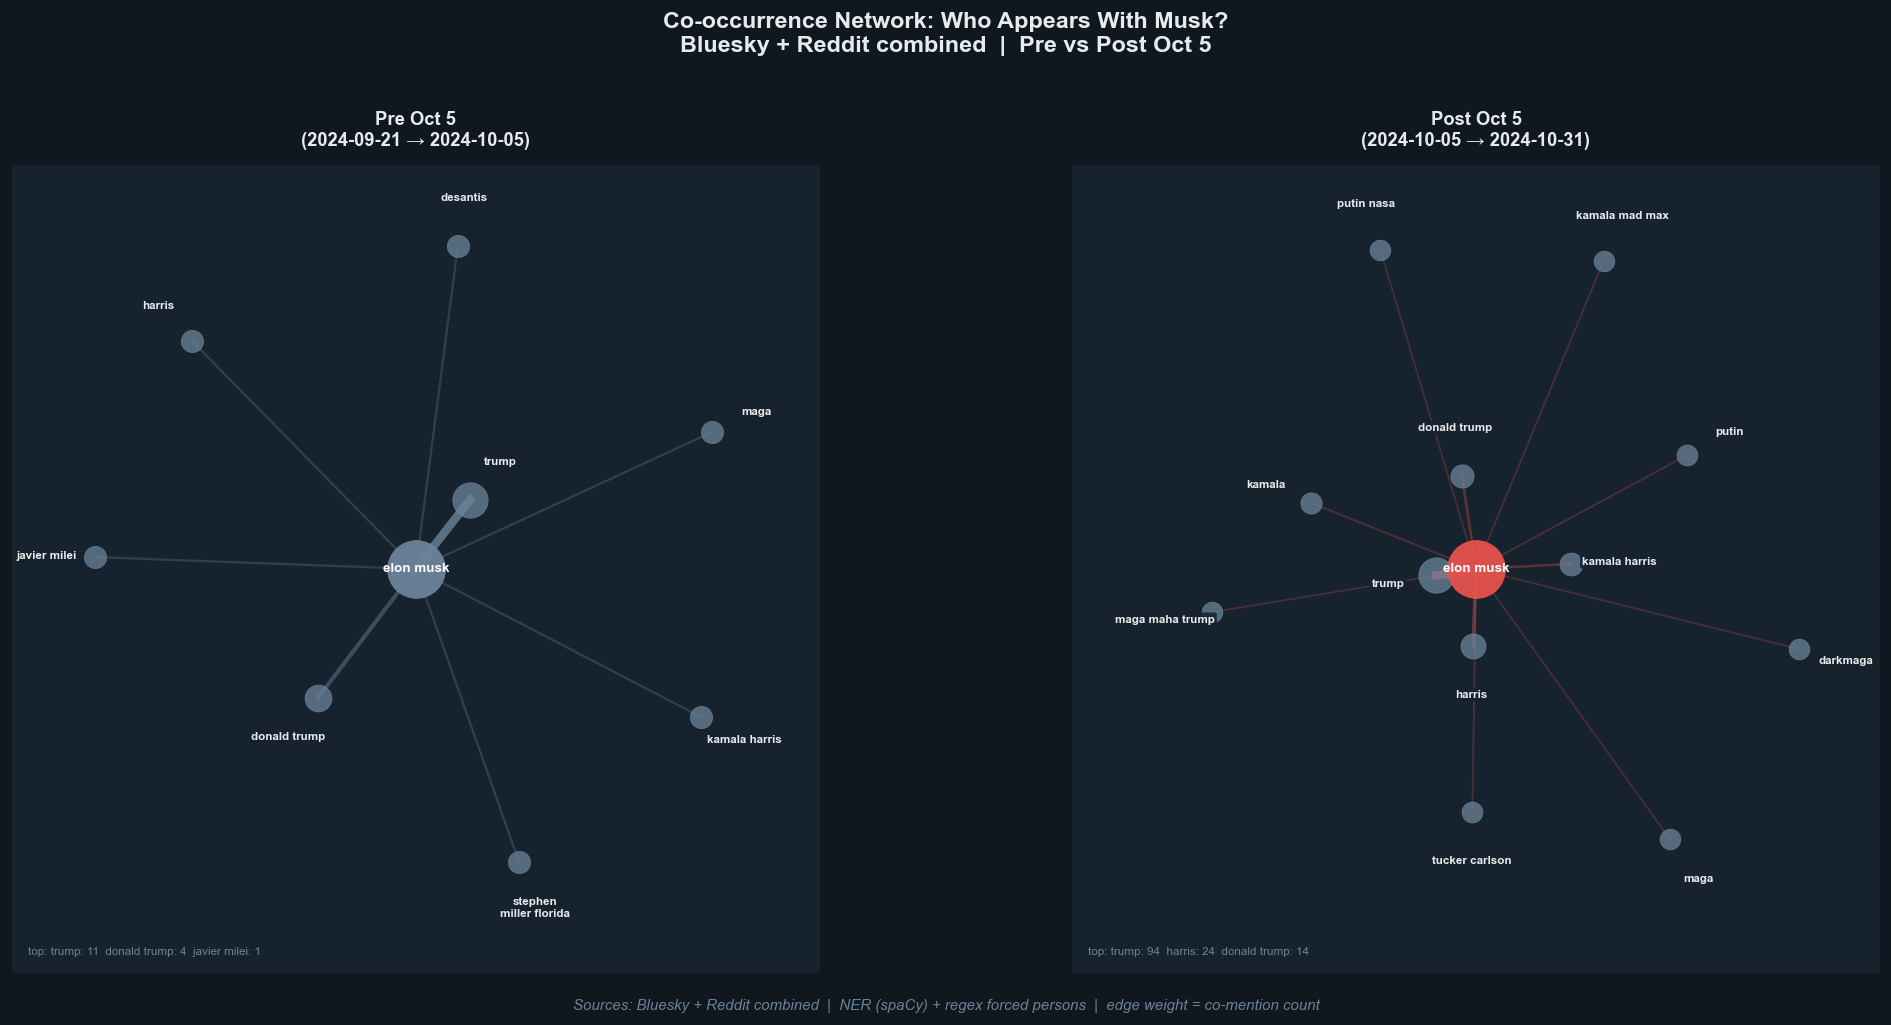

In [ ]:
def draw_cooc_network(ax, cooc_dict, title,
                      center='elon musk', node_color=E1_COLOR,
                      top_n=12):
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    if not cooc_dict:
        ax.text(0.5, 0.5, 'Not enough\nco-occurrences',
                ha='center', va='center', color=TEXT_MUTED,
                fontsize=10, transform=ax.transAxes)
        ax.set_title(title, color=TEXT_PRIMARY,
                     fontsize=14, fontweight='bold')
        return

    top_edges = sorted(cooc_dict.items(),
                       key=lambda x: x[1], reverse=True)[:top_n]
    G = nx.Graph()
    G.add_node(center)
    for (src, tgt), w in top_edges:
        G.add_edge(src, tgt, weight=w)

    fixed_pos = {center: (0, 0)}
    pos = nx.spring_layout(G, seed=42, k=1.2,
                           fixed=[center], pos=fixed_pos)
    coords     = np.array(list(pos.values()))
    max_extent = np.abs(coords).max()
    if max_extent > 0:
        scale = 0.8 / max_extent
        pos   = {n: (x * scale, y * scale) for n, (x, y) in pos.items()}

    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w   = max(weights) if weights else 1

    for (u, v), w in zip(G.edges(), weights):
        nw = w / max_w
        ax.plot([pos[u][0], pos[v][0]],
                [pos[u][1], pos[v][1]],
                color=node_color,
                linewidth=1.0 + 4.0 * nw,
                alpha=0.25 + 0.55 * nw,
                zorder=1)

    peripheral = [n for n in G.nodes() if n != center]
    for node in peripheral:
        size = 150 + 300 * (cooc_dict.get((center, node), 0) / max_w)
        ax.scatter(pos[node][0], pos[node][1],
                   s=size, color=TEXT_MUTED,
                   alpha=0.75, zorder=2)

    ax.scatter(pos[center][0], pos[center][1],
               s=1200, color=node_color,
               alpha=0.95, zorder=3)
    ax.text(pos[center][0], pos[center][1], center,
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color='white', zorder=5)

    for node in peripheral:
        x, y   = pos[node]
        dx, dy = x, y
        dist   = max((dx**2 + dy**2) ** 0.5, 0.01)
        lx     = np.clip(x + dx / dist * 0.12, -0.92, 0.92)
        ly     = np.clip(y + dy / dist * 0.12, -0.92, 0.92)
        label  = node if len(node) <= 15 else node.replace(' ', '\n', 1)
        ax.text(lx, ly, label,
                ha='center', va='center',
                fontsize=7, color=TEXT_PRIMARY,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor=BG_PANEL,
                          edgecolor='none', alpha=0.85),
                zorder=5, clip_on=True)

    top3       = sorted(cooc_dict.items(),
                        key=lambda x: x[1], reverse=True)[:3]
    legend_txt = '  '.join([f'{tgt}: {cnt}' for (_, tgt), cnt in top3])
    ax.text(0.02, 0.02, f'top: {legend_txt}',
            transform=ax.transAxes, color=TEXT_MUTED,
            fontsize=7, va='bottom')
    ax.set_title(title, color=TEXT_PRIMARY,
                 fontsize=14, fontweight='bold', pad=12)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect('equal')

# ── Build combined co-occurrence ───────────────────────────────────────────────
pre_cooc  = build_cooccurrence(pre_persons)
post_cooc = build_cooccurrence(post_persons)

print(f'Combined pre  co-occurrence pairs: {len(pre_cooc)}')
print(f'Combined post co-occurrence pairs: {len(post_cooc)}')
print('\nTop post-event co-occurrences:')
for (src, tgt), cnt in sorted(post_cooc.items(),
                               key=lambda x: x[1], reverse=True):
    print(f'  {tgt:<20} {cnt:>4}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(
    'Co-occurrence Network: Who Appears With Musk?\n'
    'Bluesky + Reddit combined  |  Pre vs Post Oct 5',
    color=TEXT_PRIMARY, fontsize=18, fontweight='bold', y=1.02
)

draw_cooc_network(
    axes[0], pre_cooc,
    title=f'Pre Oct 5\n({SYNTH_START.date()} → {E_START.date()})',
    node_color=TEXT_MUTED, top_n=12
)
draw_cooc_network(
    axes[1], post_cooc,
    title=f'Post Oct 5\n({E_START.date()} → {SYNTH_END.date()})',
    node_color=E1_COLOR, top_n=12
)

fig.text(0.5, -0.02,
         'Sources: Bluesky + Reddit combined  |  '
         'NER (spaCy) + regex forced persons  |  '
         'edge weight = co-mention count',
         ha='center', color=TEXT_MUTED, fontsize=9, style='italic')

plt.tight_layout()
plt.show()

SpaCy made wrong 'PERSON' classifications so filter out these

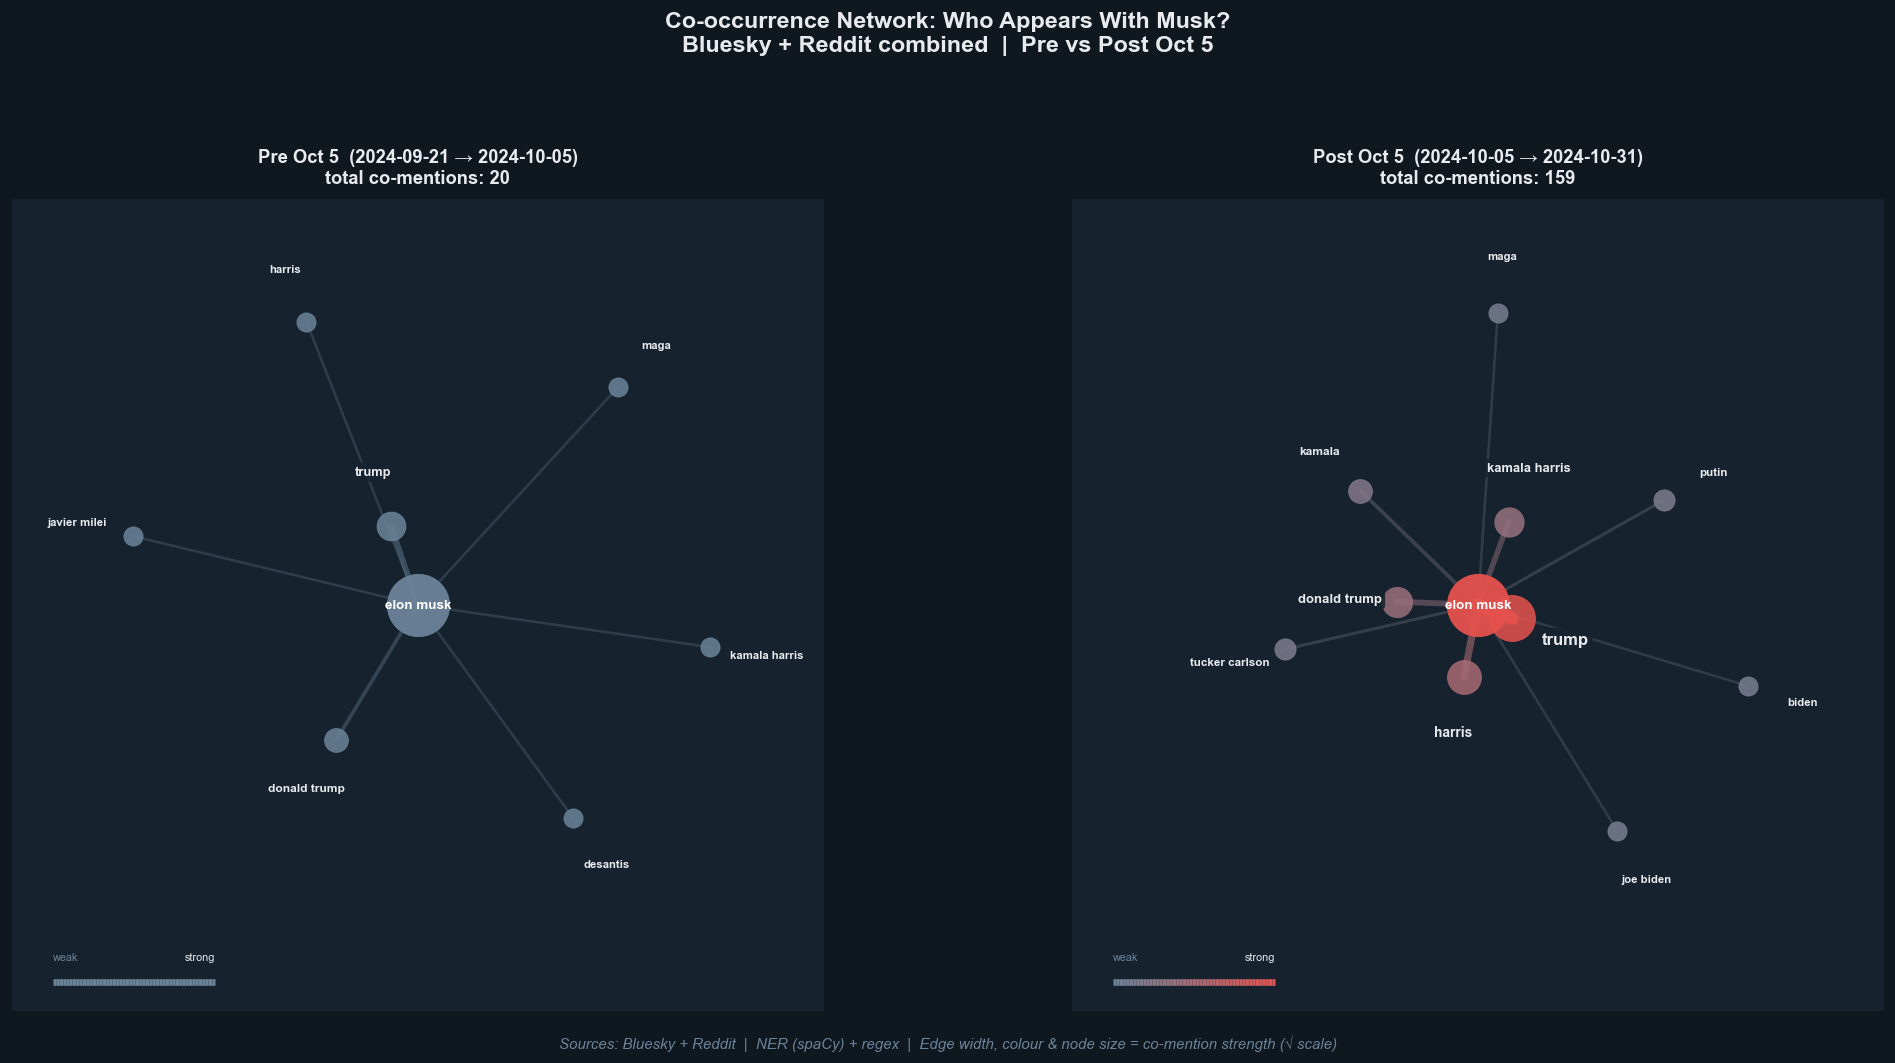

In [ ]:
# ── Filter out known spaCy misclassifications ──────────────────────────────────
NOISE_NAMES = {
    'maga maha trump', 'kamala mad max', 'putin nasa',
    'darkmaga', 'maga fearmonger', 'stephen miller florida',
    'kamala harris assassination', 'kamalaharris', 'kamala mad',
}

def clean_cooc(cooc_dict):
    return {k: v for k, v in cooc_dict.items()
            if k[1] not in NOISE_NAMES}

pre_cooc_clean  = clean_cooc(pre_cooc)
post_cooc_clean = clean_cooc(post_cooc)

global_max = max(
    max(pre_cooc_clean.values(),  default=1),
    max(post_cooc_clean.values(), default=1)
)

import matplotlib.colors as mcolors

def draw_cooc_network_v3(ax, cooc_dict, title,
                          center='elon musk', node_color=E1_COLOR,
                          top_n=12, global_max_w=1):
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    if not cooc_dict:
        ax.text(0.5, 0.5, 'Not enough\nco-occurrences',
                ha='center', va='center', color=TEXT_MUTED,
                fontsize=10, transform=ax.transAxes)
        ax.set_title(title, color=TEXT_PRIMARY,
                     fontsize=14, fontweight='bold')
        return

    top_edges = sorted(cooc_dict.items(),
                       key=lambda x: x[1], reverse=True)[:top_n]
    G = nx.Graph()
    G.add_node(center)
    for (src, tgt), w in top_edges:
        G.add_edge(src, tgt, weight=w)

    fixed_pos = {center: (0, 0)}
    pos = nx.spring_layout(G, seed=42, k=1.4,
                           fixed=[center], pos=fixed_pos)
    coords     = np.array(list(pos.values()))
    max_extent = np.abs(coords).max()
    if max_extent > 0:
        scale = 0.72 / max_extent
        pos   = {n: (x * scale, y * scale) for n, (x, y) in pos.items()}

    sqrt_max = np.sqrt(global_max_w)
    low_col  = np.array(mcolors.to_rgb(TEXT_MUTED))
    try:
        high_col = np.array(mcolors.to_rgb(node_color))
    except ValueError:
        high_col = np.array([1.0, 1.0, 1.0])

    # ── edges ─────────────────────────────────────────────────────────────────
    for (u, v) in G.edges():
        w     = G[u][v]['weight']
        nw    = np.sqrt(w) / sqrt_max
        lw    = 0.8 + 7.0 * nw
        alpha = 0.20 + 0.75 * nw
        color = tuple(low_col + nw * (high_col - low_col))
        ax.plot([pos[u][0], pos[v][0]],
                [pos[u][1], pos[v][1]],
                color=color, linewidth=lw,
                alpha=alpha, zorder=1,
                solid_capstyle='round')

    # ── peripheral nodes ──────────────────────────────────────────────────────
    peripheral = [n for n in G.nodes() if n != center]
    for node in peripheral:
        w    = cooc_dict.get((center, node), 0)
        nw   = np.sqrt(w) / sqrt_max
        size = 60 + 700 * nw
        col  = tuple(low_col + nw * (high_col - low_col))
        ax.scatter(pos[node][0], pos[node][1],
                   s=size, color=col,
                   alpha=0.85, zorder=2)

    # ── center node ───────────────────────────────────────────────────────────
    ax.scatter(0, 0, s=1400, color=node_color, alpha=0.95, zorder=3)
    ax.text(0, 0, center, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=5)

    # ── peripheral labels — no count badges ───────────────────────────────────
    for node in peripheral:
        x, y  = pos[node]
        dist  = max((x**2 + y**2) ** 0.5, 0.01)
        lx    = np.clip(x + x/dist * 0.14, -0.90, 0.90)
        ly    = np.clip(y + y/dist * 0.14, -0.90, 0.90)
        count = cooc_dict.get((center, node), 0)
        nw    = np.sqrt(count) / sqrt_max
        fsize = 6.5 + 3.5 * nw

        ax.text(lx, ly, node,
                ha='center', va='center',
                fontsize=fsize, color=TEXT_PRIMARY,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25',
                          facecolor=BG_PANEL,
                          edgecolor='none', alpha=0.88),
                zorder=5, clip_on=True)

    # ── gradient legend bar ────────────────────────────────────────────────────
    bar_x = np.linspace(-0.90, -0.50, 50)
    for i, bx in enumerate(bar_x[:-1]):
        nw  = i / len(bar_x)
        col = tuple(low_col + nw * (high_col - low_col))
        ax.plot([bx, bar_x[i+1]], [-0.93, -0.93],
                color=col, linewidth=4,
                solid_capstyle='butt')
    ax.text(-0.90, -0.88, 'weak',   color=TEXT_MUTED,
            fontsize=6.5, va='bottom')
    ax.text(-0.50, -0.88, 'strong', color=TEXT_PRIMARY,
            fontsize=6.5, va='bottom', ha='right')

    # ── panel title ───────────────────────────────────────────────────────────
    ax.set_title(title, color=TEXT_PRIMARY,
                 fontsize=14, fontweight='bold', pad=22)

    # ── total co-mentions — prominent ─────────────────────────────────────────
    ax.text(0.5, 1.02,
            f'total co-mentions: {sum(cooc_dict.values())}',
            transform=ax.transAxes, ha='center',
            color=TEXT_PRIMARY, fontsize=11, fontweight='bold')

    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect('equal')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(
    'Co-occurrence Network: Who Appears With Musk?\n'
    'Bluesky + Reddit combined  |  Pre vs Post Oct 5',
    color=TEXT_PRIMARY, fontsize=18, fontweight='bold', y=1.06
)

draw_cooc_network_v3(
    axes[0], pre_cooc_clean,
    title=f'Pre Oct 5  ({SYNTH_START.date()} → {E_START.date()})',
    node_color=TEXT_MUTED,
    top_n=10, global_max_w=global_max
)
draw_cooc_network_v3(
    axes[1], post_cooc_clean,
    title=f'Post Oct 5  ({E_START.date()} → {SYNTH_END.date()})',
    node_color=E1_COLOR,
    top_n=10, global_max_w=global_max
)

fig.text(0.5, -0.02,
         'Sources: Bluesky + Reddit  |  NER (spaCy) + regex  |  '
         'Edge width, colour & node size = co-mention strength (√ scale)',
         ha='center', color=TEXT_MUTED, fontsize=9, style='italic')
plt.tight_layout()
plt.show()

## 7. Word2Vec — Semantic Similarity Analysis

Training Word2Vec models...


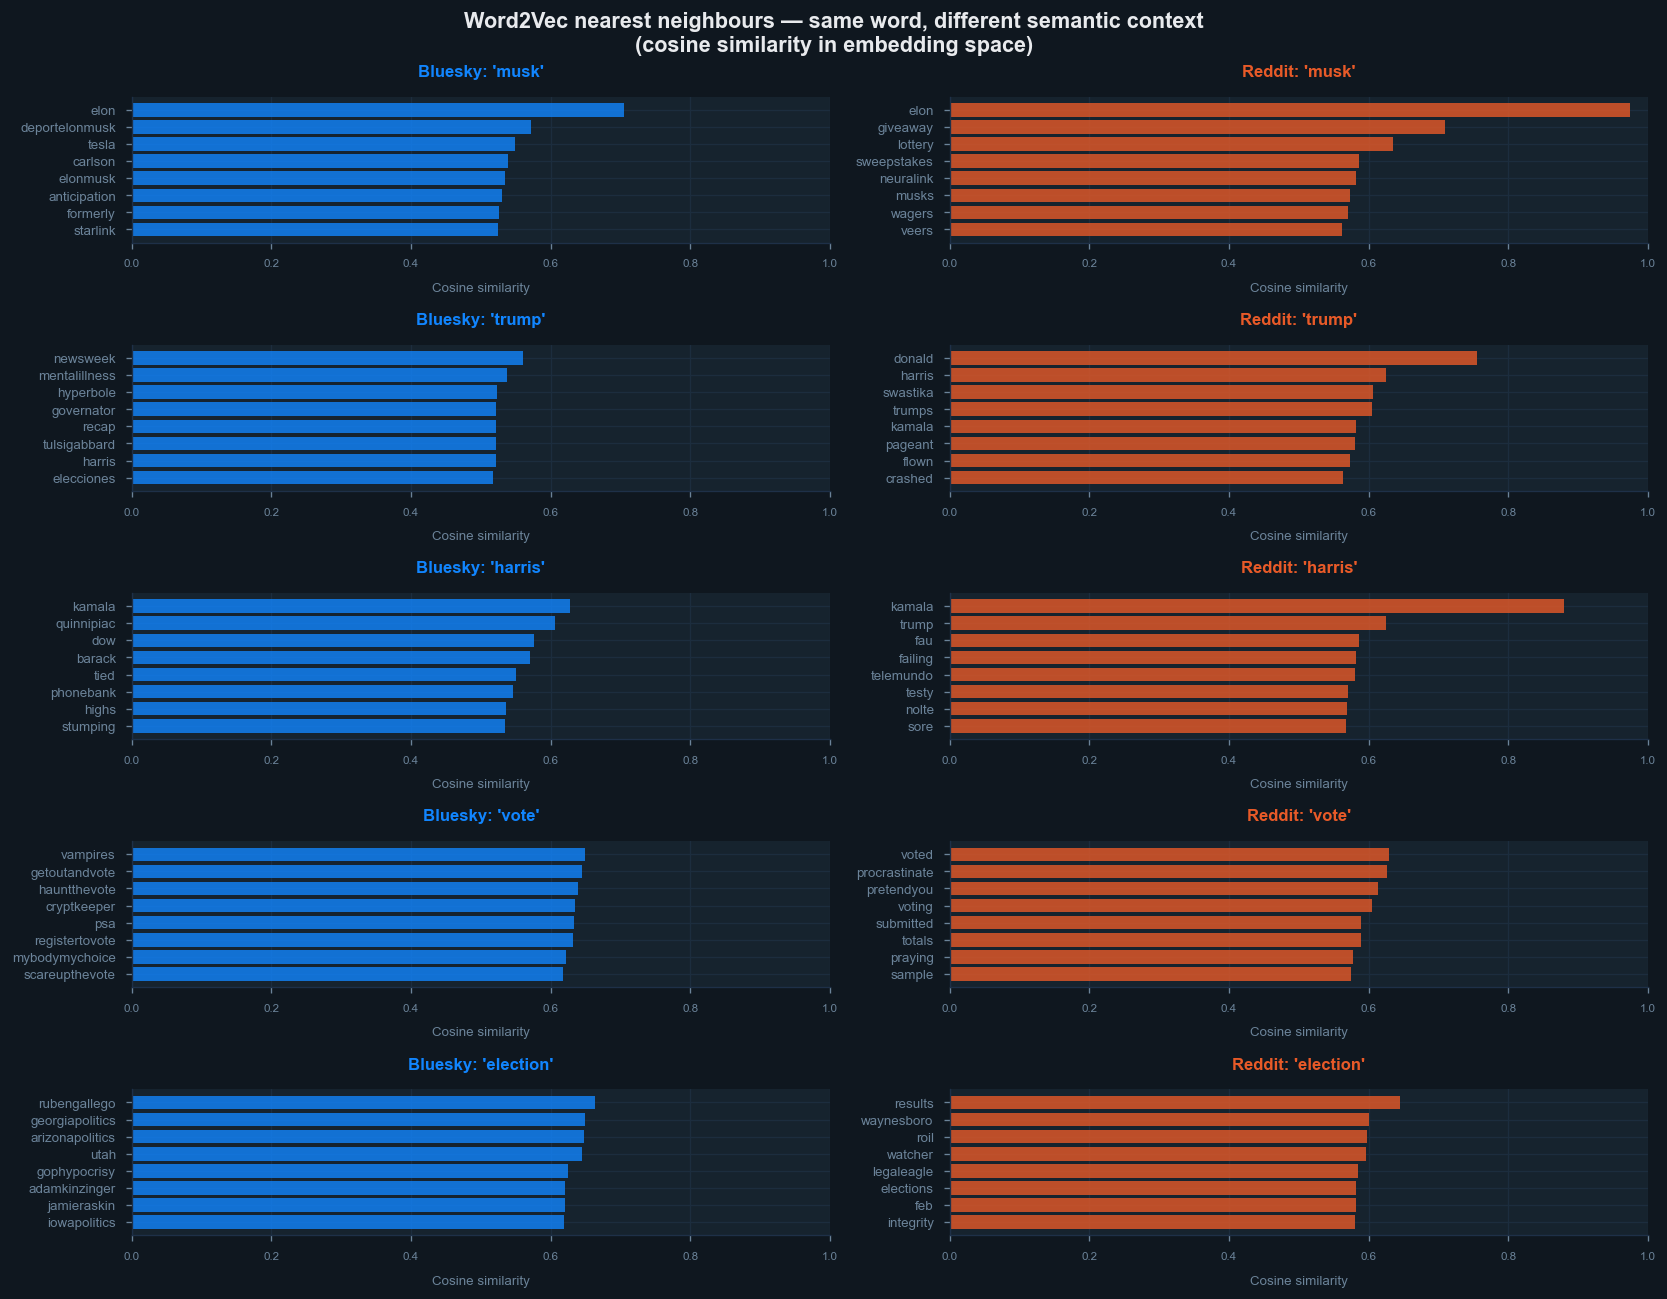

In [ ]:
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

BSKY_TEXT_COL   = 'text_clean'
REDDIT_TEXT_COL = 'text_clean'

def tokenize(texts):
    out = []
    for t in texts:
        tokens = simple_preprocess(str(t), deacc=True, min_len=3)
        tokens = [w for w in tokens if w not in stop_words]
        out.append(tokens)
    return [t for t in out if t]

print("Training Word2Vec models...")
tokens_bsky   = tokenize(bsky_arc[BSKY_TEXT_COL])
tokens_reddit = tokenize(reddit_arc[REDDIT_TEXT_COL])

w2v_bsky   = Word2Vec(tokens_bsky,   vector_size=100, window=5,
                      sg=1, epochs=30, min_count=3, seed=42)
w2v_reddit = Word2Vec(tokens_reddit, vector_size=100, window=5,
                      sg=1, epochs=30, min_count=3, seed=42)

# ── Compare nearest neighbours for key election terms ─────────────────────────
seed_words = ['musk', 'trump', 'harris', 'vote', 'election']

fig, axes = plt.subplots(len(seed_words), 2,
                          figsize=(14, len(seed_words)*2.2))
fig.suptitle("Word2Vec nearest neighbours — same word, different semantic context\n"
             "(cosine similarity in embedding space)",
             color=TEXT_PRIMARY, fontsize=18)

for row, word in enumerate(seed_words):
    for col, (model, platform, color) in enumerate([
        (w2v_bsky,   'Bluesky', BLUESKY_BLUE),
        (w2v_reddit, 'Reddit',  REDDIT_ORG),
    ]):
        ax = axes[row, col]
        ax.set_facecolor(BG_PANEL)

        if word not in model.wv:
            ax.text(0.5, 0.5, f"'{word}' not in vocab",
                    ha='center', va='center', color=TEXT_MUTED,
                    transform=ax.transAxes)
            ax.set_title(f"{platform}: '{word}'", color=color, fontsize=14)
            continue

        neighbours = model.wv.most_similar(word, topn=8)
        words_nb  = [w for w, _ in neighbours]
        sims      = [s for _, s in neighbours]

        ax.barh(words_nb[::-1], sims[::-1], color=color, alpha=0.8)
        ax.set_xlim(0, 1)
        ax.set_xlabel('Cosine similarity', color=TEXT_MUTED, fontsize=8)
        ax.set_title(f"{platform}: '{word}'", color=color, fontsize=14)
        ax.tick_params(axis='y', labelsize=8, colors=TEXT_MUTED)
        ax.tick_params(axis='x', labelsize=7, colors=TEXT_MUTED)
        for spine in ax.spines.values():
            spine.set_edgecolor(SPINE_COLOR)

fig.patch.set_facecolor(BG_DARK)
plt.tight_layout()
plt.savefig('word2vec_platform_comparison.png', dpi=130,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()

Bluesky + Musk: 

- Musk as a powerful actor to be resisted or held accountable

Reddit + Musk: 

- Users are discussing the literal prize draw, not Musk as a political figure.

Bluesky + Trump: 

- Bluesky is performing political critique

Reddit + Trump:

- Reddit is reacting to news


